<div>
<div style="font-size: 0.85em; letter-spacing: 0.08em; text-transform: uppercase; color: #1c4ed8; font-weight: 700; margin-bottom: 0.5em;">ML Research &middot; Rate Plan Design</div>
<h1 style="margin: 0 0 0.3em; font-weight: 800; letter-spacing: -0.01em;">Launch forecast, scoring, and recommendation</h1>
<p style="margin-top: 0; font-size: 1.2em; color: #444;">Notebook 2 of 2: turns the estimated choice models into a launch forecast, scores it against the withheld answer key, and recommends a launch configuration</p>
</div>

<div style="border: 2px solid #a94442; padding: 20px 30px;">
<h2>Disclosure</h2>
<ul style="margin-left: 0; padding-left: 1.25em;">
<li>All data and modeled results are synthetic, generated and validated in <code>data/00_generate_and_validate_data.ipynb</code>.</li>
<li>This notebook continues <code>01_choice_model_estimation.ipynb</code> and reads that notebook's saved outputs from <code>outputs/</code>; run it first.</li>
<li>Answer-key tables load only through <code>load_answer_key()</code>, and only in cells that score a finished forecast.</li>
</ul>
</div>

<hr>
<div>
<h2>Initialize Forecast Environment</h2>
<p>Initializes the shared imports, plotting style, file paths, constants, and helper functions used throughout sections 05–08. These match notebook 1, so either notebook runs on its own.</p>
</div>

In [1]:
# Standard Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax
from scipy.stats import norm, qmc
from scipy.cluster.vq import kmeans2
from IPython.display import display

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
TEAL = '#1f9e89'
PURPLE = '#7b4fc9'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

In [3]:
# Data Loading and Export Helpers
DATA = Path('data/synthetic')
OUTPUTS = Path('outputs')
OUTPUTS.mkdir(exist_ok = True)

MODEL_TABLES = [
    'accounts', 'usage_panel', 'plan_events', 'plan_catalog', 'price_history', 'markets',
    'conjoint_responses', 'conjoint_respondents',
]
ANSWER_KEY_TABLES = [
    'ground_truth', 'true_plan_events', 'value_launch_counterfactual',
    'counterfactual_launch', 'counterfactual_grid', 'generator_parameters',
]


def load(name):
    """Loads a table the carrier could actually hold. Answer-key tables are refused."""

    if name in ANSWER_KEY_TABLES:
        raise PermissionError(f'{name} is part of the withheld answer key; use load_answer_key() only when scoring')
    if name not in MODEL_TABLES:
        raise KeyError(f'unknown table {name!r}')

    return pd.read_parquet(DATA / f'{name}.parquet')


def load_answer_key(name):
    """Loads a withheld table. Used only in scoring cells, never to fit or tune a model."""

    if name not in ANSWER_KEY_TABLES:
        raise KeyError(f'{name!r} is not an answer-key table')

    return pd.read_parquet(DATA / f'{name}.parquet')


def load_output(name):
    """Loads a table saved by an earlier section."""

    return pd.read_parquet(OUTPUTS / f'{name}.parquet')


def save_output(df, name):

    path = OUTPUTS / f'{name}.parquet'
    df.to_parquet(path, index = False)

    return path

In [4]:
# Domain Constants
ALTS = ['premium', 'standard', 'value', 'essentials', 'comp_premium', 'comp_value', 'outside']
OWN_PLANS = ['premium', 'standard', 'value', 'essentials']
ORIGINS = ['premium', 'standard', 'value', 'competitor', 'outside']
ORIGIN_OF = {
    'premium': 'premium', 'standard': 'standard', 'value': 'value',
    'comp_premium': 'competitor', 'comp_value': 'competitor', 'outside': 'outside',
}

N_MONTHS = 24
N_HORIZON = 12
ADDL_LINE_RATE = 0.65

ESSENTIALS_PRICES = np.arange(35.0, 55.1, 2.5)
ESSENTIALS_BUNDLES = ['lean', 'lean_hotspot', 'lean_30gb', 'lean_hd']
ELIGIBILITY = ['open', 'no_multiline_discount', 'new_lines_only']
CONFIG_KEYS = ['bundle', 'eligibility', 'essentials_price']
REFERENCE_CONFIG = ('lean', 'open', 45.0)

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>05 · Back-Test on the Value Launch</h1>
<p><strong>Purpose:</strong> Tests the forecasting approach on a launch that already happened. Everything that could absorb the launch's effect is refitted on months 1–13 only, the launch of <code>value</code> in month 14 is forecast through month 24, and the forecast's source of volume is scored against the true incremental source.</p>
<p><strong>Architecture:</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Reasoning</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1</td><td style="text-align: left; vertical-align: top;">Refit plan constants, nests, and switching on pre-launch history</td><td style="text-align: left; vertical-align: top;">A back-test is only honest if nothing observed after the launch informs the model.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2</td><td style="text-align: left; vertical-align: top;">Paired monthly microsimulation with and without <code>value</code>, on shared random numbers</td><td style="text-align: left; vertical-align: top;">The same engine forecasts <code>essentials</code> in section 06, so the back-test validates the method rather than a one-off calculation.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3</td><td style="text-align: left; vertical-align: top;">Three-way comparison: carrier records, forecasts, and truth</td><td style="text-align: left; vertical-align: top;">Source of volume cannot be read off plan events; the gaps show why a forecast is needed, and how good each model's forecast is.</td></tr>
</tbody>
</table>
</div>

In [5]:
# Load Forecast Inputs
catalog_all = load('plan_catalog').set_index('plan')
price_history = load('price_history')
usage_panel = load('usage_panel')
accounts = load('accounts').set_index('account_id')
plan_events = load('plan_events')
markets = load('markets').set_index('market_id')

choice_occasions = load_output('choice_occasions')
demand_estimates = load_output('demand_estimates').set_index('account_id')
prices_faced = load_output('prices_faced').set_index(['market_id', 'month'])
SIGMA_USAGE = load_output('rp_meta').set_index('key').loc['sigma_usage', 'value']
joint_estimates = load_output('joint_estimates')
lc_coefficients = load_output('lc_class_coefficients').set_index('class')
lc_membership = load_output('lc_membership').set_index('class')
lc_meta = load_output('lc_meta').set_index('key')['value']
sp_respondents = load_output('sp_respondents').set_index('respondent_id')
lc_posteriors = load_output('lc_respondent_posteriors').set_index('respondent_id')
sp_design = load_output('sp_design')

CLASS_NAMES = lc_meta['class_names'].split(';')
LC_MU, LC_ALPHA = float(lc_meta['survey_scale_mu']), float(lc_meta['price_attenuation_alpha'])
SEED = 20260917
VALUE_LAUNCH = int(price_history.loc[price_history['plan'].eq('value') & price_history['available'], 'month'].min())
print(f'value launched in month {VALUE_LAUNCH} · {len(choice_occasions):,} choice occasions · {len(CLASS_NAMES)} taste classes')

value launched in month 14 · 1,012,958 choice occasions · 3 taste classes


<hr>
<div>
<h2>1 · Refitting on Pre-Launch History</h2>
<p><strong>Purpose:</strong> Builds three forecast models and refits the parts of each that could absorb the launch's effect, using months 1–13 only.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Three Forecast Models.</strong> Each combines tastes, plan constants, a substitution structure, and a switching model.
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Model</th><th style="text-align: left;">Tastes</th><th style="text-align: left;">Substitution</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">Flat logit</td><td style="text-align: left; vertical-align: top;">One set of coefficients, from the section 03 flat joint model</td><td style="text-align: left; vertical-align: top;">Proportional to share</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Nested logit</td><td style="text-align: left; vertical-align: top;">One set, from the section 03 price-tier joint model</td><td style="text-align: left; vertical-align: top;">Price-tier nests</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Latent class</td><td style="text-align: left; vertical-align: top;">Section 04 class coefficients, converted to real-world scale, mixed by each account's class probabilities</td><td style="text-align: left; vertical-align: top;">Price-tier nests</td></tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Refitted on Months 1–13.</strong> Plan constants and nest parameters, holding each model's tastes fixed, on customers' plan changes before the launch; and the switching model, on every pre-launch account-month.</li>
<li style="margin-bottom: 0.7em;"><strong>Not Refitted.</strong> Tastes come from the conjoint, treated as if fielded before the launch: its profiles are unbranded, so it carries no information about <code>value</code>'s uptake. Demand estimates use all 24 months of usage, a minor leak since usage itself does not depend on which plans exist.</li>
<li style="margin-bottom: 0.7em;"><strong>Pre-Launch Assumptions.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>value</code> had never been chosen, so its constants are borrowed from <code>standard</code>, the nearest existing plan.</li>
<li>No launch had happened, so the promotion's effect on re-shopping stands in for launch marketing.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [6]:
# Define Utility Building Blocks
RP_ALTS = ['premium', 'standard', 'value', 'comp_premium', 'comp_value', 'outside']
OWN_PLANS = ['premium', 'standard', 'value', 'essentials']
FEATURES = ['price', 'throttle', 'hotspot', 'roam', 'stream', 'perks']
JOINT_SCALE = np.array([10.0, 1.0, 1.0, 1.0, 1.0, 10.0])
CONSTANT_PLANS = RP_ALTS[:-1]
TRIGGERS = ['device_upgrade', 'throttled_last_month', 'care_contact', 'promo', 'launch_window']
TREES = {
    'flat': None,
    'price tier': [['premium', 'comp_premium'], ['standard'], ['value', 'essentials', 'comp_value', 'outside']],
}


def nest_indices(tree, alts):
    if TREES[tree] is None:
        return [[j] for j in range(len(alts))]
    position = {a: i for i, a in enumerate(alts)}
    return [[position[a] for a in nest if a in position] for nest in TREES[tree] if any(a in position for a in nest)]


def throttled_gb(mu, cap, sigma = SIGMA_USAGE):
    mu, cap = np.broadcast_arrays(np.asarray(mu, dtype = float), np.asarray(cap, dtype = float))
    finite = np.isfinite(cap)
    safe_cap = np.where(finite, cap, 1.0)
    d = (mu - np.log(safe_cap)) / sigma
    return np.where(finite, np.maximum(np.exp(mu + sigma ** 2 / 2) * norm.cdf(d + sigma) - safe_cap * norm.cdf(d), 0.0), 0.0)


def multiline_factor(lines):
    return (1 + ADDL_LINE_RATE * (lines - 1)) / lines


def plan_features(people, catalog, list_price):
    """Real-world features (n, J, 6) for people facing the plans in `catalog` at per-row or shared list prices."""
    n, J = len(people), len(catalog)
    lines = people['lines'].to_numpy()
    list_price = np.broadcast_to(np.asarray(list_price, dtype = float), (n, J))
    tier = catalog['roaming_tier'].to_numpy()[None, :]
    price = list_price * np.where(catalog['multiline_discount'].to_numpy(dtype = bool)[None, :], multiline_factor(lines)[:, None], 1.0)
    return np.stack([
        price,
        throttled_gb(people['mu'].to_numpy()[:, None], catalog['data_gb'].to_numpy()[None, :]),
        np.maximum(people['hotspot_need'].to_numpy()[:, None] - catalog['hotspot_gb'].to_numpy()[None, :], 0.0),
        people['intl_rate'].to_numpy()[:, None] * (tier < 2) + people['na_rate'].to_numpy()[:, None] * (tier < 1),
        np.broadcast_to(catalog['stream_tier'].to_numpy(dtype = float), (n, J)),
        np.broadcast_to(catalog['perks_value'].to_numpy(dtype = float), (n, J)),
    ], axis = 2)


def constant_design(lines, alts, borrow):
    """Plan × line-count constant indicators (n, J, 25); `borrow` maps an unseen plan to an existing plan's constants."""
    C = np.zeros((len(lines), len(alts), len(CONSTANT_PLANS) * 5))
    for j, alt in enumerate(alts):
        source = borrow.get(alt, alt)
        if source in CONSTANT_PLANS:
            k = CONSTANT_PLANS.index(source)
            for l in range(1, 6):
                C[lines == l, j, k * 5 + l - 1] = 1.0
    return C


COVARIATES = [c for c in lc_membership.columns if c != 'intercept']
MEMBERSHIP = lc_membership.loc[CLASS_NAMES, ['intercept'] + COVARIATES].to_numpy()


def class_probabilities(people):
    Z = pd.DataFrame(index = people.index)
    Z['lines'] = people['lines']
    for band in ['18-29', '45-64', '65+']:
        Z[f'age {band}'] = people['age_band'].eq(band).astype(float)
    for tier in ['low', 'high']:
        Z[f'income {tier}'] = people['zip_income_tier'].eq(tier).astype(float)
    for tier in ['budget', 'flagship']:
        Z[f'device {tier}'] = people['device_tier'].eq(tier).astype(float)
    for plan in ['premium', 'standard', 'value', 'competitor']:
        Z[f'current {plan}'] = people['current_plan'].eq(plan).astype(float)
    Z['log data demand'] = people['mu']
    Z['log international days'] = np.log1p(people['intl_rate'])
    Z['hotspot user'] = (people['hotspot_need'] > 0).astype(float)
    standardized = (Z[COVARIATES] - lc_membership.loc['standardization mean', COVARIATES]) / lc_membership.loc['standardization std', COVARIATES]
    return softmax(np.column_stack([np.ones(len(Z)), standardized.to_numpy()]) @ MEMBERSHIP.T, axis = 1)


def nested_probabilities(V, available, nests, lam):
    """Log-probabilities (n, J) and the inclusive value over available alternatives."""
    V = np.where(available, V, -np.inf)
    with np.errstate(all = 'ignore'):
        inclusive = np.stack([logsumexp(V[:, idx] / lam[m], axis = 1) for m, idx in enumerate(nests)], axis = 1)
        composite = np.where(np.isfinite(inclusive), inclusive * lam[None, :], -np.inf)
        total = logsumexp(composite, axis = 1)
        log_p = np.full(V.shape, -np.inf)
        for m, idx in enumerate(nests):
            log_p[:, idx] = V[:, idx] / lam[m] - inclusive[:, m][:, None] + composite[:, m][:, None] - total[:, None]
    return np.where(available, log_p, -np.inf), total


# Real-world tastes
def joint_parameters(tree):
    theta = joint_estimates[joint_estimates['tree'] == tree].set_index('term')['theta']
    return theta, theta[FEATURES].to_numpy() / JOINT_SCALE

CLASS_BETA = np.column_stack([lc_coefficients.loc[CLASS_NAMES, f].to_numpy() for f in FEATURES]) / LC_MU
CLASS_BETA[:, 0] /= LC_ALPHA
MODELS = {
    'flat logit': {'tree': 'flat', 'beta': joint_parameters('flat')[1], 'start': joint_parameters('flat')[0]},
    'nested logit': {'tree': 'price tier', 'beta': joint_parameters('price tier')[1], 'start': joint_parameters('price tier')[0]},
    'latent class': {'tree': 'price tier', 'beta': CLASS_BETA, 'start': joint_parameters('price tier')[0]},
}
display(pd.DataFrame(CLASS_BETA, index = CLASS_NAMES, columns = FEATURES).style.format('{:.4f}')
        .set_caption('Latent Class Tastes on the Real-World Scale (per dollar)'))

,price,throttle,hotspot,roam,stream,perks
Price-Driven,-0.0859,-0.0387,-0.0714,0.0163,0.0130,0.0153
Mainstream,-0.0663,-0.0562,-0.0213,-0.1652,0.2388,0.0079
Premium Travelers,-0.0250,-0.0601,-0.0442,-0.5092,0.4462,0.0272


In [7]:
# Build Pre-Launch Estimation Data
list_prices = price_history.pivot(index = 'month', columns = 'plan', values = 'list_price')
availability = price_history.pivot(index = 'month', columns = 'plan', values = 'available').astype(bool)
rp_catalog = catalog_all.loc[RP_ALTS]
ALT = {a: i for i, a in enumerate(RP_ALTS)}


def occasion_people(o):
    people = accounts.loc[o['account_id']].join(demand_estimates[['mu', 'hotspot_need', 'intl_rate', 'na_rate']], how = 'left')
    return people.assign(lines = o['lines'].to_numpy(), current_plan = o['plan'].to_numpy()).reset_index(drop = True)


def occasion_design(o):
    """Features, constants, availability without the current plan, chosen set, and class probabilities for occasions."""
    people = occasion_people(o)
    list_price = (list_prices.loc[o['month'], RP_ALTS].to_numpy()
                  - prices_faced.reindex(pd.MultiIndex.from_frame(o[['market_id', 'month']])).reindex(columns = RP_ALTS, fill_value = 0.0).fillna(0.0).to_numpy())
    X = plan_features(people, rp_catalog, list_price)
    C = constant_design(o['lines'].to_numpy(), RP_ALTS, {})
    open_now = availability.loc[o['month'], RP_ALTS].to_numpy().copy()
    rows, current = np.arange(len(o)), o['plan'].map(ALT).to_numpy()
    destinations = open_now.copy()
    destinations[rows, current] = False
    chosen = np.zeros((len(o), len(RP_ALTS)), dtype = bool)
    for alt in RP_ALTS:
        chosen[o['outcome'].to_numpy() == ('competitor' if alt.startswith('comp_') else alt), ALT[alt]] = True
    return X, C, open_now, destinations, chosen, class_probabilities(people)

pre_launch = choice_occasions[choice_occasions['month'] < VALUE_LAUNCH]
pre_changes = pre_launch[pre_launch['changed']]
X_pre, C_pre, _, dest_pre, chosen_pre, classes_pre = occasion_design(pre_changes)
print(f'{len(pre_launch):,} pre-launch account-months · {len(pre_changes):,} plan changes')

551,380 pre-launch account-months · 6,846 plan changes


In [8]:
# Refit Plan Constants and Nests
def model_utilities(model, X, C, constants):
    base = C @ constants
    if model == 'latent class':
        return np.einsum('njk,ck->njc', X, MODELS[model]['beta']) + base[..., None]
    return X @ MODELS[model]['beta'] + base


def fit_constants(model, X, C, destinations, chosen, class_p, start_constants, start_lam):
    nests = nest_indices(MODELS[model]['tree'], RP_ALTS)
    free = [m for m, idx in enumerate(nests) if len(idx) > 1]

    def objective(theta):
        lam = np.ones(len(nests))
        lam[free] = theta[25:]
        V = model_utilities(model, X, C, theta[:25])
        if model == 'latent class':
            by_class = np.stack([
                logsumexp(np.where(chosen, nested_probabilities(V[..., c], destinations, nests, lam)[0], -np.inf), axis = 1)
                for c in range(V.shape[2])
            ], axis = 1)
            return -logsumexp(by_class + np.log(class_p), axis = 1).sum()
        return -logsumexp(np.where(chosen, nested_probabilities(V, destinations, nests, lam)[0], -np.inf), axis = 1).sum()

    result = minimize(objective, np.r_[start_constants, start_lam[:len(free)]], method = 'L-BFGS-B',
                      bounds = [(None, None)] * 25 + [(0.05, 1.0)] * len(free), options = {'maxiter': 500})
    lam = np.ones(len(nests))
    lam[free] = result.x[25:]
    return result.x[:25].copy(), lam, -result.fun


def borrow_constants(constants, target, source):
    constants = constants.copy()
    t, s = CONSTANT_PLANS.index(target), CONSTANT_PLANS.index(source)
    constants[t * 5:t * 5 + 5] = constants[s * 5:s * 5 + 5]
    return constants

backtest = {}
for model, spec in MODELS.items():
    start = spec['start']
    start_constants = start[[f'{a} × {l} lines' for a in CONSTANT_PLANS for l in range(1, 6)]].to_numpy()
    start_lam = start[[t for t in start.index if t.startswith('λ')]].to_numpy()
    constants, lam, loglik = fit_constants(model, X_pre, C_pre, dest_pre, chosen_pre, classes_pre, start_constants, start_lam)
    backtest[model] = {'constants': borrow_constants(constants, 'value', 'standard'), 'lam': lam, 'loglik': loglik}

display(pd.DataFrame({
    model: {
        'log-likelihood, pre-launch changes': b['loglik'],
        'nest parameters': ', '.join(f'{v:.2f}' for v in b['lam'] if v < 0.999) or '—',
    }
    for model, b in backtest.items()
}).T.style.format({'log-likelihood, pre-launch changes': '{:,.1f}'}).set_caption('Plan Constants Refitted on Months 1–13'))

,"log-likelihood, pre-launch changes",nest parameters
flat logit,"-6,172.2",—
nested logit,"-6,146.3","0.32, 0.48"
latent class,"-6,023.5",0.39


In [9]:
# Refit Switching Models
def inclusive_gain(V, destinations, current, nests, lam):
    rows = np.arange(len(V))
    _, inclusive = nested_probabilities(V, destinations, nests, lam)
    return inclusive - V[rows, current]


def switching_gain(model, o, constants, lam, chunk = 100_000):
    nests = nest_indices(MODELS[model]['tree'], RP_ALTS)
    gain = np.empty(len(o))
    for start in range(0, len(o), chunk):
        part = o.iloc[start:start + chunk]
        X, C, _, destinations, _, class_p = occasion_design(part)
        V = model_utilities(model, X, C, constants)
        current = part['plan'].map(ALT).to_numpy()
        if model == 'latent class':
            gain[start:start + chunk] = sum(class_p[:, c] * inclusive_gain(V[..., c], destinations, current, nests, lam) for c in range(V.shape[2]))
        else:
            gain[start:start + chunk] = inclusive_gain(V, destinations, current, nests, lam)
    return gain


def fit_switching(o, gain):
    terms = [t for t in TRIGGERS if o[t].any()]
    Z = np.column_stack([np.ones(len(o)), o[terms].to_numpy(dtype = float), gain])
    y = o['changed'].to_numpy(dtype = float)

    def objective(b):
        eta = Z @ b
        return -(y * eta - np.logaddexp(0, eta)).sum(), -(Z.T @ (y - 1 / (1 + np.exp(-eta))))

    result = minimize(objective, np.zeros(Z.shape[1]), jac = True, method = 'L-BFGS-B')
    return dict(zip(['intercept'] + terms + ['gain'], result.x))

for model, b in backtest.items():
    switching = fit_switching(pre_launch, switching_gain(model, pre_launch, b['constants'], b['lam']))
    switching.setdefault('launch_window', switching['promo'])
    b['switching'] = switching

display(pd.DataFrame({m: b['switching'] for m, b in backtest.items()}).T[['intercept'] + TRIGGERS + ['gain']]
        .style.format('{:.3f}').set_caption('Switching Models Refitted on Months 1–13 (launch window = promotion effect)'))

,intercept,device_upgrade,throttled_last_month,care_contact,promo,launch_window,gain
flat logit,-4.664,1.109,0.838,0.727,0.266,0.266,0.230
nested logit,-4.621,1.108,0.870,0.727,0.267,0.267,0.184
latent class,-4.857,1.131,0.797,0.727,0.366,0.366,0.531


<hr>
<div>
<h2>2 · Forecasting the Value Launch</h2>
<p><strong>Purpose:</strong> Simulates months 14–24 twice for every model, with and without <code>value</code>, on the same random numbers.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Existing Customers.</strong> Everyone who was a customer at the start of month 14, each month:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Triggers are drawn from each account's pre-launch device upgrade and care contact rates (shrunk toward the average), and throttling from its estimated demand against its current plan's cap.</li>
<li>The switching model gives the probability of changing; a customer who changes picks a destination by utility plus errors drawn from the model's nest structure, so choices follow that model's substitution pattern exactly.</li>
<li>Involuntary disconnects occur at the pre-launch rate.</li>
<li>Under the latent class model, each account's class is drawn once from its class probabilities and kept.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>New Customers.</strong> Households with competitors or outside postpaid are represented by the non-customer survey respondents, drawn by survey weight.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each month's arrivals choose among the carrier's plans and staying where they are; staying uses their current plan's features and the survey's keep-current constants.</li>
<li>The monthly number of arrivals is calibrated so the model reproduces the average pre-launch gross adds.</li>
<li>New customers keep their first plan through month 24.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Shared Random Numbers.</strong> Every draw comes from a generator seeded by replication and month, drawn the same way in both worlds, so any difference between them is caused by <code>value</code>. Results average three replications.</li>
<li style="margin-bottom: 0.7em;"><strong>Source of Volume.</strong> A household's origin is where it is at month 24 in the world without <code>value</code>, which is how the answer key defines it.</li>
<li style="margin-bottom: 0.7em;"><strong>Observable Check.</strong> The forecast number of <code>value</code> customers by month is compared with the carrier's own account counts, which needs no answer key.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [10]:
# Define Launch Simulator
def positive_stable(alpha, size, rng):
    u = np.clip(rng.uniform(0, np.pi, size), 1e-12, np.pi - 1e-12)
    e = rng.exponential(1.0, size)
    a = np.sin(alpha * u) ** (alpha / (1 - alpha)) * np.sin((1 - alpha) * u) / np.sin(u) ** (1 / (1 - alpha))
    return (a / e) ** ((1 - alpha) / alpha)


def nested_errors(n, width, nests, lam, rng):
    """Errors whose argmax follows a nested logit; draws depend only on the nest layout, never on availability."""
    xi = rng.gumbel(size = (n, width))
    eps = xi.copy()
    for m, idx in enumerate(nests):
        if len(idx) > 1 and lam[m] < 0.999:
            eps[:, idx] = lam[m] * (xi[:, idx] + np.log(positive_stable(lam[m], n, rng))[:, None])
    return eps


def draw_classes(class_p, rng):
    return (np.cumsum(class_p, axis = 1) < rng.random((len(class_p), 1))).sum(axis = 1)


def market_population(history_end, start):
    """Customers in `start` (account_id, plan, lines) with trigger rates from months before `history_end`, and the prospect pool."""
    history = usage_panel[usage_panel['month'] < history_end].groupby('account_id').agg(
        months = ('month', 'size'), upgrades = ('device_upgrade', 'sum'), contacts = ('care_contact', 'sum'))
    upgrade_rate = history['upgrades'].sum() / history['months'].sum()
    care_rate = history['contacts'].sum() / history['months'].sum()
    customers = (start.set_index('account_id')
                 .join(accounts[['age_band', 'zip_income_tier', 'device_tier', 'market_id']])
                 .join(demand_estimates[['mu', 'hotspot_need', 'intl_rate', 'na_rate']])
                 .join(history))
    customers['p_upgrade'] = (customers['upgrades'].fillna(0) + 24 * upgrade_rate) / (customers['months'].fillna(0) + 24)
    customers['p_care'] = (customers['contacts'].fillna(0) + 24 * care_rate) / (customers['months'].fillna(0) + 24)
    customers['current_plan'] = customers['plan']

    prospects = sp_respondents[~sp_respondents['is_customer']].join(lc_posteriors[[f'posterior {c}' for c in CLASS_NAMES]])
    keep = sp_design[sp_design['option'].eq('keep_current') & sp_design['task'].eq(1)].set_index('respondent_id').loc[prospects.index]
    involuntary = plan_events[(plan_events['event'] == 'churn') & plan_events['involuntary'] & (plan_events['month'] < history_end)]
    return {
        'customers': customers,
        'class_p': class_probabilities(customers),
        'prospects': prospects,
        'prospect_stay_X': keep[FEATURES].to_numpy(),
        'prospect_class_p': prospects[[f'posterior {c}' for c in CLASS_NAMES]].to_numpy(),
        'prospect_weight': (prospects['weight'] / prospects['weight'].sum()).to_numpy(),
        'involuntary_rate': len(involuntary) / (usage_panel['month'] < history_end).sum(),
    }


def configure_market(population, alts, catalog, list_price, borrow, eligibility = 'open', new_plan = None, costs = None):
    """Features, constants, throttling, and optionally monthly margins for a population facing the plans in `alts`."""
    catalog = catalog.loc[alts].copy()
    if new_plan is not None and eligibility == 'no_multiline_discount':
        catalog.loc[new_plan, 'multiline_discount'] = False
    customers, prospects = population['customers'], population['prospects']
    market = dict(population, alts = alts, catalog = catalog, new_plan = new_plan, eligibility = eligibility)
    market['X'] = plan_features(customers, catalog, list_price)
    market['C'] = constant_design(customers['lines'].to_numpy(), alts, borrow)
    market['p_throttle'] = norm.sf((np.log(catalog['data_gb'].to_numpy())[None, :] - customers['mu'].to_numpy()[:, None]) / SIGMA_USAGE)
    market['prospect_X'] = plan_features(prospects, catalog, list_price)
    market['prospect_C'] = constant_design(prospects['lines'].to_numpy(), alts, borrow)
    if costs is not None:
        market['margin'] = costs(customers, catalog, market['X'])
        market['prospect_margin'] = costs(prospects, catalog, market['prospect_X'])
    return market


def build_market(history_end, alts, catalog, list_price, borrow, eligibility = 'open', new_plan = None, start = None):
    if start is None:
        start = usage_panel[usage_panel['month'] == history_end][['account_id', 'plan', 'lines']]
    return configure_market(market_population(history_end, start), alts, catalog, list_price, borrow, eligibility, new_plan)


def prospect_utilities(model, market, constants):
    """Utilities of the carrier's plans (alternatives) plus staying where they are (last column)."""
    theta = joint_parameters(MODELS[model]['tree'])[0]
    X, C, stay = market['prospect_X'], market['prospect_C'], market['prospect_stay_X']
    if model == 'latent class':
        keep = (lc_coefficients.loc[CLASS_NAMES, 'keep_current'] + lc_coefficients.loc[CLASS_NAMES, 'keep_current × non-customer']).to_numpy() / LC_MU
        own = np.einsum('pjk,ck->pjc', X, CLASS_BETA) + (C @ constants)[..., None]
        return np.concatenate([own, (stay @ CLASS_BETA.T + keep)[:, None, :]], axis = 1)
    beta = MODELS[model]['beta'].copy()
    beta[0] *= np.exp(theta['δ price × non-customer'])
    own = X @ beta + C @ constants
    return np.concatenate([own, (stay @ beta + theta['keep current'] + theta['keep current × non-customer'])[:, None]], axis = 1)


def model_lam(fit, nests):
    return fit['lam'] if len(fit['lam']) == len(nests) else np.ones(len(nests))


def prospect_join_probability(model, market, fit, open_plans):
    alts = market['alts']
    V = prospect_utilities(model, market, fit['constants'])
    available = np.array([a in open_plans for a in alts] + [True])
    nests = nest_indices(MODELS[model]['tree'], alts)
    nests_all, lam_all = nests + [[len(alts)]], np.r_[model_lam(fit, nests), 1.0]

    def join(V2):
        log_p, _ = nested_probabilities(V2, np.broadcast_to(available, V2.shape), nests_all, lam_all)
        return 1 - np.exp(log_p[:, -1])

    p = sum(market['prospect_class_p'][:, c] * join(V[..., c]) for c in range(V.shape[2])) if model == 'latent class' else join(V)
    return np.sum(market['prospect_weight'] * p)


def make_draws(model, market, fit, months, arrival_slots, replication, seed = SEED):
    """Every random draw for one replication, in a fixed order, so worlds and configurations can share them."""
    alts = market['alts']
    J, H = len(alts), len(market['customers'])
    nests = nest_indices(MODELS[model]['tree'], alts)
    lam = model_lam(fit, nests)
    setup = np.random.default_rng([seed, replication, 0])
    draws = {'classes': draw_classes(market['class_p'], setup), 'throttle': setup.random(H), 'months': []}
    for month in months:
        rng = np.random.default_rng([seed, replication, month])
        uniforms = rng.random((5, H))
        errors = nested_errors(H, J, nests, lam, rng)
        pick = rng.choice(len(market['prospect_weight']), size = arrival_slots, p = market['prospect_weight'])
        prospect_class = draw_classes(market['prospect_class_p'][pick], rng)
        prospect_errors = nested_errors(arrival_slots, J + 1, nests + [[J]], np.r_[lam, 1.0], rng)
        draws['months'].append({'uniforms': uniforms, 'errors': errors, 'pick': pick, 'prospect_class': prospect_class, 'prospect_errors': prospect_errors})
    return draws


def simulate_market(model, market, fit, months, with_new, launch_months, arrival_slots, replication,
                    launch_lift = None, active_arrivals = None, draws = None, seed = SEED):
    """One world of the paired simulation: monthly customer states, arrival choices, and margin if the market has it."""
    alts, new_plan = market['alts'], market['new_plan']
    J = len(alts)
    index = {a: i for i, a in enumerate(alts)}
    own = np.array([index[a] for a in alts if a in OWN_PLANS])
    nests = nest_indices(MODELS[model]['tree'], alts)
    lam, switching = model_lam(fit, nests), fit['switching']
    customers = market['customers']
    H = len(customers)
    months = list(months)
    active_arrivals = active_arrivals or {}
    draws = draws or make_draws(model, market, fit, months, arrival_slots, replication, seed)

    V = model_utilities(model, market['X'], market['C'], fit['constants'])
    if model == 'latent class':
        V = V[np.arange(H), :, draws['classes']]
    state = customers['plan'].map(index).to_numpy()
    throttled_last = draws['throttle'] < market['p_throttle'][np.arange(H), state]

    open_customers = np.ones(J, dtype = bool)
    open_prospects = np.array([a in OWN_PLANS for a in alts] + [True])
    if new_plan is not None:
        open_customers[index[new_plan]] = with_new and market['eligibility'] != 'new_lines_only'
        open_prospects[index[new_plan]] = with_new

    V_prospect = prospect_utilities(model, market, fit['constants'])
    lift = np.ones(H) if launch_lift is None else launch_lift
    has_margin = 'margin' in market
    margin = 0.0
    states, arrival_choices, arrival_templates = [], [], []

    for t, month in enumerate(months):
        d = draws['months'][t]
        u_upgrade, u_care, u_throttle, u_change, u_involuntary = d['uniforms']
        errors = d['errors']
        rows = np.arange(H)
        is_own = np.isin(state, own)
        if has_margin:
            margin += np.where(is_own, market['margin'][rows, state], 0.0).sum()

        destinations = np.broadcast_to(open_customers, (H, J)).copy()
        destinations[rows, state] = False
        gain = inclusive_gain(V, destinations, state, nests, lam)
        launch = float(with_new and month in launch_months)
        eta = (switching['intercept'] + switching['device_upgrade'] * (u_upgrade < customers['p_upgrade'].to_numpy())
               + switching['throttled_last_month'] * throttled_last + switching['care_contact'] * (u_care < customers['p_care'].to_numpy())
               + switching['launch_window'] * launch * lift + switching['gain'] * gain)
        change = is_own & (u_change < 1 / (1 + np.exp(-eta)))
        destination = np.where(destinations, V + errors, -np.inf).argmax(axis = 1)
        involuntary = is_own & ~change & (u_involuntary < market['involuntary_rate'])
        throttled_last = u_throttle < market['p_throttle'][rows, state]
        state = np.where(change, destination, np.where(involuntary, index['outside'], state))
        states.append(state.copy())

        pick, prospect_class, prospect_errors = d['pick'], d['prospect_class'], d['prospect_errors']
        Vp = V_prospect[pick, :, prospect_class] if model == 'latent class' else V_prospect[pick]
        choice = np.where(open_prospects[None, :], Vp + prospect_errors, -np.inf).argmax(axis = 1)
        active = active_arrivals.get(month, arrival_slots)
        choice[active:] = J
        arrival_choices.append(choice)
        arrival_templates.append(market['prospects']['current_plan'].to_numpy()[pick])
        if has_margin:
            joined = choice < J
            margin += market['prospect_margin'][pick[joined], choice[joined]].sum() * (len(months) - t - 1)

    return {'states': np.array(states), 'arrivals': np.array(arrival_choices), 'templates': np.array(arrival_templates), 'margin': margin}


def source_of_volume(with_new, without, market, new_plan):
    """Households on the new plan at the end of the horizon, by where they would be without it."""
    alts = market['alts']
    J = len(alts)
    names = np.array(alts + ['stay'])
    collapse = {'premium': 'premium', 'standard': 'standard', 'value': 'value', 'essentials': 'essentials',
                'comp_premium': 'competitor', 'comp_value': 'competitor', 'outside': 'outside'}
    target = alts.index(new_plan)
    on_new = with_new['states'][-1] == target
    origins = [pd.Series(names[without['states'][-1][on_new]]).map(collapse)]
    joined = with_new['arrivals'] == target
    stayed = without['arrivals'][joined] == J
    origin_arrivals = np.where(stayed, np.where(with_new['templates'][joined] == 'competitor', 'competitor', 'outside'),
                               pd.Series(names[without['arrivals'][joined]]).map(collapse).fillna('outside').to_numpy())
    origins.append(pd.Series(origin_arrivals))
    return pd.concat(origins).value_counts().reindex(['premium', 'standard', 'value', 'competitor', 'outside'], fill_value = 0)

,monthly arrivals,value households at month 24
flat logit,325,"2,615"
nested logit,368,"4,246"
latent class,376,"4,566"


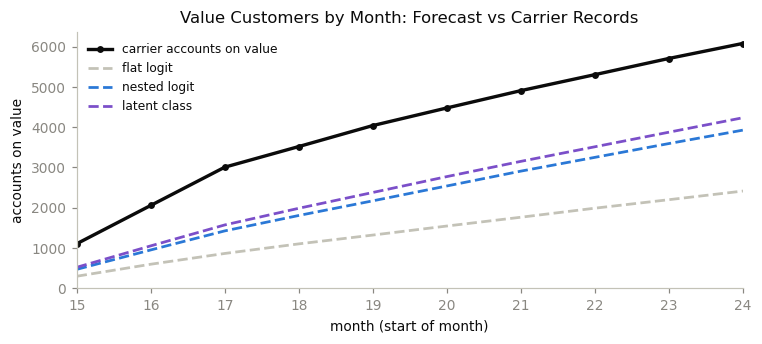

In [11]:
# Run Back-Test Simulations
BACKTEST_MONTHS = range(VALUE_LAUNCH, N_MONTHS + 1)
BACKTEST_LAUNCH_MONTHS = set(range(VALUE_LAUNCH, VALUE_LAUNCH + 3))
REPLICATIONS = 3
backtest_market = build_market(VALUE_LAUNCH, RP_ALTS, catalog_all, list_prices.loc[VALUE_LAUNCH, RP_ALTS].to_numpy(), borrow = {}, new_plan = 'value')
observed_gross_adds = plan_events[(plan_events['event'] == 'gross_add') & (plan_events['month'] < VALUE_LAUNCH)].groupby('month').size().mean()

backtest_results, monthly_value = {}, {}
for model, fit in backtest.items():
    arrivals = int(round(observed_gross_adds / prospect_join_probability(model, backtest_market, fit, ['premium', 'standard'])))
    counts, path = [], []
    for rep in range(REPLICATIONS):
        with_value = simulate_market(model, backtest_market, fit, BACKTEST_MONTHS, True, BACKTEST_LAUNCH_MONTHS, arrivals, rep)
        without_value = simulate_market(model, backtest_market, fit, BACKTEST_MONTHS, False, BACKTEST_LAUNCH_MONTHS, arrivals, rep)
        counts.append(source_of_volume(with_value, without_value, backtest_market, 'value'))
        v = ALT['value']
        path.append((with_value['states'] == v).sum(axis = 1) + np.cumsum((with_value['arrivals'] == v).sum(axis = 1)))
    fit['arrivals'] = arrivals
    backtest_results[model] = pd.concat(counts, axis = 1).mean(axis = 1)
    monthly_value[model] = np.mean(path, axis = 0)

display(pd.DataFrame({m: {'monthly arrivals': f['arrivals'], 'value households at month 24': backtest_results[m].sum()}
                      for m, f in backtest.items()}).T.style.format('{:,.0f}').set_caption('Back-Test Forecasts'))

observed_value = usage_panel[usage_panel['plan'] == 'value'].groupby('month').size().reindex(range(VALUE_LAUNCH + 1, N_MONTHS + 1), fill_value = 0)
fig, ax = plt.subplots(figsize = (7, 3.2))
ax.plot(observed_value.index, observed_value.to_numpy(), color = INK, linewidth = 2.2, marker = 'o', markersize = 3.5, label = 'carrier accounts on value')
for (model, path), color in zip(monthly_value.items(), [BASELINE, ACCENT, PURPLE]):
    ax.plot(np.arange(VALUE_LAUNCH + 1, N_MONTHS + 2)[:len(path)], path, color = color, linewidth = 1.8, linestyle = '--', label = model)
ax.set_xlim(VALUE_LAUNCH + 1, N_MONTHS)
ax.set_ylim(bottom = 0)
ax.set_title('Value Customers by Month: Forecast vs Carrier Records')
ax.set_xlabel('month (start of month)')
ax.set_ylabel('accounts on value')
ax.legend(frameon = False, fontsize = 8)
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>3 · Plan Events vs Forecast vs Truth</h2>
<p><strong>Purpose:</strong> Compares where <code>value</code>'s customers came from according to the carrier's plan records, each model's forecast, and the withheld truth.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Carrier Records.</strong> For accounts on <code>value</code> at month 24, the plan they moved from; gross adds count as <code>competitor</code> (port-ins) or <code>outside</code> (new lines).</li>
<li style="margin-bottom: 0.7em;"><strong>Truth.</strong> The answer key's month-24 state of every household on <code>value</code> in the world where it never launched. This is the only cell in the section that reads the answer key.</li>
<li style="margin-bottom: 0.7em;"><strong>What Matters Most.</strong> The share drawn from <code>premium</code> and <code>standard</code>, the higher-margin plans, since that is where the cannibalization cost sits.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

,premium,standard,competitor,outside,premium + standard,households,error in premium + standard (points),origin distance
carrier records,13.7%,42.3%,20.3%,23.7%,56.0%,"6,078",+10.4,10.4%
flat logit,18.6%,45.7%,24.5%,11.3%,64.2%,"2,615",+18.6,18.6%
nested logit,12.7%,40.0%,31.7%,15.6%,52.6%,"4,246",+7.1,11.1%
latent class,12.5%,43.8%,27.6%,16.1%,56.4%,"4,566",+10.8,10.8%
truth,10.5%,35.1%,27.6%,26.8%,45.6%,"6,474",+0.0,0.0%


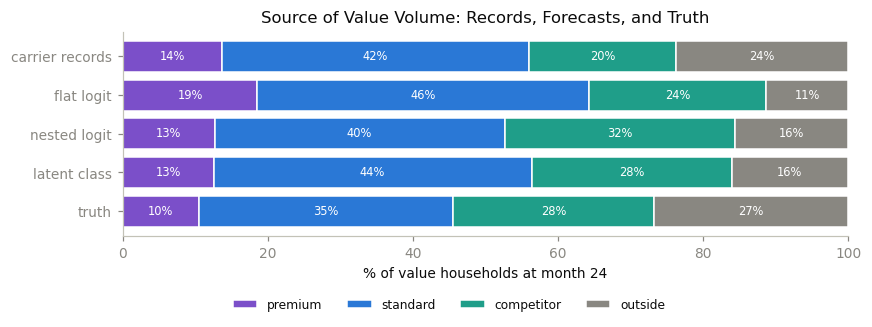

In [12]:
# Score Against the Answer Key
SOURCES = ['premium', 'standard', 'competitor', 'outside']
collapse_truth = {'premium': 'premium', 'standard': 'standard', 'comp_premium': 'competitor', 'comp_value': 'competitor', 'outside': 'outside'}

value_truth = load_answer_key('value_launch_counterfactual')
on_value = value_truth['state_m24_actual'].eq('value')
truth_counts = value_truth.loc[on_value, 'state_m24_no_value'].map(collapse_truth).value_counts().reindex(SOURCES, fill_value = 0)

records = (plan_events[plan_events['to_plan'].eq('value')].sort_values('month').groupby('account_id')['from_plan'].last()
           .reindex(usage_panel.loc[usage_panel['month'].eq(N_MONTHS) & usage_panel['plan'].eq('value'), 'account_id'])
           .map({'premium': 'premium', 'standard': 'standard', 'competitor': 'competitor', 'new': 'outside'}))
records_counts = records.value_counts().reindex(SOURCES, fill_value = 0)

rows = {'carrier records': records_counts, **{m: r.reindex(SOURCES) for m, r in backtest_results.items()}, 'truth': truth_counts}
scorecard = pd.DataFrame({name: counts / counts.sum() for name, counts in rows.items()}).T
scorecard['premium + standard'] = scorecard['premium'] + scorecard['standard']
scorecard['households'] = [counts.sum() for counts in rows.values()]
scorecard['error in premium + standard (points)'] = (scorecard['premium + standard'] - scorecard.loc['truth', 'premium + standard']) * 100
scorecard['origin distance'] = 0.5 * (scorecard[SOURCES] - scorecard.loc['truth', SOURCES]).abs().sum(axis = 1)
display(scorecard.style.format({**{s: '{:.1%}' for s in SOURCES}, 'premium + standard': '{:.1%}', 'households': '{:,.0f}',
                                'error in premium + standard (points)': '{:+.1f}', 'origin distance': '{:.1%}'})
        .set_caption('Where Value Customers Came From'))

fig, ax = plt.subplots(figsize = (8, 3.2))
order = list(rows)
left = np.zeros(len(order))
for source, color in zip(SOURCES, [PURPLE, ACCENT, TEAL, MUTED]):
    values = scorecard.loc[order, source].to_numpy() * 100
    ax.barh(order, values, left = left, color = color, edgecolor = SURFACE, label = source)
    for i, (l, v) in enumerate(zip(left, values)):
        if v > 7:
            ax.text(l + v / 2, i, f'{v:.0f}%', ha = 'center', va = 'center', fontsize = 7.5, color = SURFACE)
    left += values
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('% of value households at month 24')
ax.set_title('Source of Value Volume: Records, Forecasts, and Truth')
ax.legend(frameon = False, fontsize = 8, ncol = 4, loc = 'upper center', bbox_to_anchor = (0.45, -0.25))
plt.tight_layout()
plt.show()

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>06 · The Launch Simulation</h1>
<p><strong>Purpose:</strong> Forecasts the 12 months after launch for every configuration: how many households take <code>essentials</code>, which plan or carrier each would otherwise have been on, and the net contribution margin once downgrades, competitor wins, and saved churners are all counted.</p>
<p><strong>Architecture:</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Reasoning</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1</td><td style="text-align: left; vertical-align: top;">Refit on all 24 months</td><td style="text-align: left; vertical-align: top;">The <code>value</code> launch is now history, so its effect on re-shopping and on new customers can be estimated instead of assumed.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2</td><td style="text-align: left; vertical-align: top;">Margin model from the carrier's own billing</td><td style="text-align: left; vertical-align: top;">Monthly revenue per line always makes a cheaper plan look worse; margin by household over 12 months shows what the launch is actually worth.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3</td><td style="text-align: left; vertical-align: top;">Section 05's paired simulation across 9 prices × 4 bundles × 3 eligibility rules for each model</td><td style="text-align: left; vertical-align: top;">Shared random numbers make the difference between each launch and no launch the launch effect alone, for every configuration at once.</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Full-History Refit and Launch Marketing</h2>
<p><strong>Purpose:</strong> Refits each model's plan constants, nests, and switching on all 24 months, and measures launch marketing from the <code>value</code> launch.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Refit.</strong> The same procedure as section 05, on every plan change and account-month. Tastes stay fixed at their section 03 and 04 values.</li>
<li style="margin-bottom: 0.7em;"><strong>Launch Marketing for Customers.</strong> The switching model's launch-window coefficient is now estimated from months 14–16. The <code>value</code> launch was marketed the same way everywhere; for <code>essentials</code>, each market's planned intensity (quiet 0, standard 1, heavy 2) scales that coefficient.</li>
<li style="margin-bottom: 0.7em;"><strong>Launch Marketing for New Customers.</strong> Gross adds during the <code>value</code> launch window, relative to the months after it, give a marketing multiplier on arrivals. For <code>essentials</code> it is scaled by the customer-weighted average market intensity.</li>
<li style="margin-bottom: 0.7em;"><strong>Arrivals.</strong> The monthly number of arriving households is calibrated so each model reproduces average gross adds in months 17–24, after the launch window, with <code>value</code> in the portfolio.</li>
<li style="margin-bottom: 0.7em;"><strong>New Plan Constants.</strong> <code>essentials</code> borrows <code>value</code>'s constants and joins the value-tier nest, as in section 03.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [13]:
# Refit on Full History
all_changes = choice_occasions[choice_occasions['changed']]
X_all, C_all, _, dest_all, chosen_all, classes_all = occasion_design(all_changes)

launch_fits = {}
for model, spec in MODELS.items():
    start = spec['start']
    start_constants = start[[f'{a} × {l} lines' for a in CONSTANT_PLANS for l in range(1, 6)]].to_numpy()
    start_lam = start[[t for t in start.index if t.startswith('λ')]].to_numpy()
    constants, lam, loglik = fit_constants(model, X_all, C_all, dest_all, chosen_all, classes_all, start_constants, start_lam)
    switching = fit_switching(choice_occasions, switching_gain(model, choice_occasions, constants, lam))
    launch_fits[model] = {'constants': constants, 'lam': lam, 'loglik': loglik, 'switching': switching}

display(pd.DataFrame({
    model: {**{'log-likelihood, all changes': f['loglik'], 'nest parameters': ', '.join(f'{v:.2f}' for v in f['lam'] if v < 0.999) or '—'},
            **{f'switching: {k}': v for k, v in f['switching'].items()}}
    for model, f in launch_fits.items()
}).T.style.format({'log-likelihood, all changes': '{:,.1f}', **{f'switching: {k}': '{:.3f}' for k in ['intercept', 'gain'] + TRIGGERS}})
    .set_caption('Forecast Models Refitted on All 24 Months'))

gross_adds = plan_events[plan_events['event'] == 'gross_add'].groupby('month').size()
launch_window_adds = gross_adds.loc[VALUE_LAUNCH:VALUE_LAUNCH + 2].mean()
steady_adds = gross_adds.loc[VALUE_LAUNCH + 3:N_MONTHS].mean()
ARRIVAL_MARKETING = launch_window_adds / steady_adds
print(f'Gross adds: {launch_window_adds:,.0f} per month in the value launch window vs {steady_adds:,.0f} after it · arrival marketing multiplier {ARRIVAL_MARKETING:.2f}×')

,"log-likelihood, all changes",nest parameters,switching: intercept,switching: device_upgrade,switching: throttled_last_month,switching: care_contact,switching: promo,switching: launch_window,switching: gain
flat logit,"-16,285.7",—,-4.625,1.078,0.837,0.784,0.207,0.622,0.269
nested logit,"-16,215.0","0.33, 0.57",-4.565,1.077,0.834,0.783,0.181,0.671,0.221
latent class,"-15,979.3",0.70,-4.861,1.103,0.851,0.786,0.353,0.540,0.555


Gross adds: 841 per month in the value launch window vs 458 after it · arrival marketing multiplier 1.84×


<hr>
<div>
<h2>2 · Margin Model</h2>
<p><strong>Purpose:</strong> Estimates each household's monthly contribution margin on any plan, including plans it is not on.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Cost per Line.</strong> Bills and margins give cost per line for every account-month. After subtracting each plan's known perks cost, it is regressed on observed GB per line and covered roaming days.</li>
<li style="margin-bottom: 0.7em;"><strong>Usage above the Cap.</strong> A throttled month's usage above the cap is compared with the expected excess demand given the account's demand estimate; the ratio is the share of excess demand that still shows up as usage and cost.</li>
<li style="margin-bottom: 0.7em;"><strong>Expected Margin on Any Plan.</strong> Lines × (price per line − cost per line), where cost uses expected usage under that plan's cap, expected covered roaming days under its roaming tier, and its perks cost. Competitor and <code>outside</code> months earn nothing.</li>
<li style="margin-bottom: 0.7em;"><strong>Check.</strong> Expected margin on each account's actual month-24 plan is compared with its billed margin.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [14]:
# Estimate Margin Model
billing = usage_panel.join(demand_estimates['mu'], on = 'account_id')
tier = billing['plan'].map(catalog_all['roaming_tier'])
billing['covered_roam_days'] = billing['intl_roam_days'] * (tier >= 2) + billing['na_roam_days'] * (tier >= 1)
billing['cost_ex_perks'] = billing['price_per_line'] - billing['margin'] / billing['lines'] - billing['plan'].map(catalog_all['perks_cost'])

design = np.column_stack([np.ones(len(billing)), billing['gb_per_line'], billing['covered_roam_days']])
cost_coef = np.linalg.lstsq(design, billing['cost_ex_perks'].to_numpy(), rcond = None)[0]
cost_r2 = 1 - np.var(billing['cost_ex_perks'] - design @ cost_coef) / np.var(billing['cost_ex_perks'])

throttled = billing[billing['throttled'] & np.isfinite(billing['plan'].map(catalog_all['data_gb']))]
cap = throttled['plan'].map(catalog_all['data_gb']).to_numpy()
excess = throttled_gb(throttled['mu'].to_numpy(), cap) / norm.sf((np.log(cap) - throttled['mu'].to_numpy()) / SIGMA_USAGE)
THROTTLED_USE = (throttled['gb_per_line'].to_numpy() - cap).sum() / excess.sum()

display(pd.DataFrame({'estimate': [cost_coef[0], cost_coef[1], cost_coef[2], THROTTLED_USE, cost_r2]},
                     index = ['cost per line, fixed ($)', 'cost per GB used ($)', 'cost per covered roaming day ($)',
                              'share of excess demand used when throttled', 'R² of cost regression'])
        .style.format('{:.3f}').set_caption('Margin Model'))


def monthly_margin(people, catalog, X):
    """Expected monthly margin (n, J) on each plan: lines × (price per line − expected cost per line)."""
    mean_demand = np.exp(people['mu'].to_numpy() + SIGMA_USAGE ** 2 / 2)[:, None]
    used = mean_demand - (1 - THROTTLED_USE) * X[..., 1]
    tier = catalog['roaming_tier'].to_numpy()[None, :]
    covered = people['intl_rate'].to_numpy()[:, None] * (tier >= 2) + people['na_rate'].to_numpy()[:, None] * (tier >= 1)
    cost = cost_coef[0] + cost_coef[1] * used + cost_coef[2] * covered + catalog['perks_cost'].to_numpy()[None, :]
    margin = people['lines'].to_numpy()[:, None] * (X[..., 0] - cost)
    return np.where(np.array([a in OWN_PLANS for a in catalog.index])[None, :], margin, 0.0)

month_24 = usage_panel[usage_panel['month'] == N_MONTHS]
check_people = month_24.set_index('account_id').join(demand_estimates[['mu', 'intl_rate', 'na_rate']])
check_X = plan_features(check_people.assign(hotspot_need = 0.0), catalog_all.loc[RP_ALTS], list_prices.loc[N_MONTHS, RP_ALTS].to_numpy())
expected = monthly_margin(check_people, catalog_all.loc[RP_ALTS], check_X)[np.arange(len(check_people)), check_people['plan'].map(ALT).to_numpy()]
display(pd.DataFrame({'billed': check_people['margin'].groupby(check_people['plan']).mean(),
                      'expected': pd.Series(expected, index = check_people.index).groupby(check_people['plan']).mean()})
        .reindex(['value', 'standard', 'premium']).style.format('${:,.2f}').set_caption('Month-24 Margin per Account: Billed vs Expected'))

,estimate
"cost per line, fixed ($)",16.000
cost per GB used ($),0.350
cost per covered roaming day ($),3.000
share of excess demand used when throttled,0.462
R² of cost regression,1.000


,billed,expected
plan,,
value,$45.99,$45.91
standard,$77.40,$77.40
premium,$98.04,$98.38


<hr>
<div>
<h2>3 · Simulating 12 Months per Configuration</h2>
<p><strong>Purpose:</strong> Runs the paired simulation for months 25–36 for every configuration and every model.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Starting Point.</strong> Customers at the start of month 25: every month-24 customer whose month-24 choice kept them with the carrier, on the plan they chose.</li>
<li style="margin-bottom: 0.7em;"><strong>Configurations.</strong> <code>essentials</code> at &#36;35–&#36;55 in &#36;2.50 steps; four bundles that vary what it gives up (base <code>lean</code>: 20 GB, no hotspot, SD; plus a 5 GB hotspot, a 30 GB cap, or HD streaming); and three eligibility rules (<code>open</code>, <code>no_multiline_discount</code>, <code>new_lines_only</code>).</li>
<li style="margin-bottom: 0.7em;"><strong>One Set of Draws.</strong> For each model and replication, every random draw is generated once and shared by the no-launch world and all 108 launch worlds, so configurations are compared on identical customers, triggers, and errors.</li>
<li style="margin-bottom: 0.7em;"><strong>Outputs per Configuration.</strong> Households on <code>essentials</code> at month 36 by origin, and 12-month margin with launch minus without, averaged over three replications. This is the forecast format section 07 scores.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [15]:
# Build Launch Markets
LAUNCH_START = N_MONTHS + 1
HORIZON = list(range(LAUNCH_START, LAUNCH_START + N_HORIZON))
LAUNCH_MONTHS = set(range(LAUNCH_START, LAUNCH_START + 3))
LAUNCH_ALTS = RP_ALTS + ['essentials']
ESSENTIALS_SPECS = {
    'lean': {'data_gb': 20.0, 'hotspot_gb': 0.0, 'stream_tier': 0},
    'lean_hotspot': {'data_gb': 20.0, 'hotspot_gb': 5.0, 'stream_tier': 0},
    'lean_30gb': {'data_gb': 30.0, 'hotspot_gb': 0.0, 'stream_tier': 0},
    'lean_hd': {'data_gb': 20.0, 'hotspot_gb': 0.0, 'stream_tier': 1},
}


def essentials_catalog(bundle, price):
    catalog = catalog_all.loc[RP_ALTS].copy()
    row = catalog.loc['value'].copy()
    row[['list_price', 'roaming_tier', 'perks_value', 'perks_cost', 'multiline_discount']] = [price, 0, 0.0, 0.0, True]
    for column, value in ESSENTIALS_SPECS[bundle].items():
        row[column] = value
    catalog.loc['essentials'] = row
    return catalog

month_24_choices = choice_occasions[(choice_occasions['month'] == N_MONTHS) & choice_occasions['outcome'].isin(['premium', 'standard', 'value'])]
launch_start = month_24_choices[['account_id', 'lines']].assign(plan = month_24_choices['outcome'].to_numpy())
launch_population = market_population(LAUNCH_START, launch_start)

intensity = markets.loc[launch_population['customers']['market_id'], 'launch_intensity'].to_numpy(dtype = float)
arrival_multiplier = 1 + (ARRIVAL_MARKETING - 1) * intensity.mean()


def launch_market(bundle, eligibility, price):
    catalog = essentials_catalog(bundle, price)
    list_price = np.r_[list_prices.loc[N_MONTHS, RP_ALTS].to_numpy(), price]
    return configure_market(launch_population, LAUNCH_ALTS, catalog, list_price, borrow = {'essentials': 'value'},
                            eligibility = eligibility, new_plan = 'essentials', costs = monthly_margin)

reference_market = launch_market(*REFERENCE_CONFIG[:2], REFERENCE_CONFIG[2])
arrival_plan = {}
for model, fit in launch_fits.items():
    steady = int(round(steady_adds / prospect_join_probability(model, reference_market, fit, ['premium', 'standard', 'value'])))
    arrival_plan[model] = {
        'slots': int(np.ceil(steady * arrival_multiplier)),
        'without launch': {m: steady for m in HORIZON},
        'with launch': {m: int(round(steady * (arrival_multiplier if m in LAUNCH_MONTHS else 1))) for m in HORIZON},
    }

print(f'{len(launch_population["customers"]):,} customers at the start of month {LAUNCH_START} · '
      f'mean launch intensity {intensity.mean():.2f} · arrival multiplier in launch months {arrival_multiplier:.2f}×')
display(pd.DataFrame({m: {'arrivals per month': a['without launch'][LAUNCH_START], 'arrivals per launch month': a['with launch'][LAUNCH_START]}
                      for m, a in arrival_plan.items()}).T.style.format('{:,.0f}').set_caption('Calibrated Arrivals'))

42,124 customers at the start of month 25 · mean launch intensity 1.01 · arrival multiplier in launch months 1.85×


,arrivals per month,arrivals per launch month
flat logit,486,899
nested logit,515,952
latent class,485,897


In [16]:
# Run Launch Simulations
import time

configurations = [(b, e, p) for b in ESSENTIALS_BUNDLES for e in ELIGIBILITY for p in ESSENTIALS_PRICES]
markets_by_config = {config: launch_market(*config) for config in configurations}
REPLICATIONS = 3

started = time.time()
volume_rows, margin_rows = {m: {} for m in MODELS}, {m: {} for m in MODELS}
for model, fit in launch_fits.items():
    plan = arrival_plan[model]
    for rep in range(REPLICATIONS):
        draws = make_draws(model, reference_market, fit, HORIZON, plan['slots'], rep)
        without = simulate_market(model, reference_market, fit, HORIZON, False, LAUNCH_MONTHS, plan['slots'], rep,
                                  active_arrivals = plan['without launch'], draws = draws)
        for config in configurations:
            market = markets_by_config[config]
            with_launch = simulate_market(model, market, fit, HORIZON, True, LAUNCH_MONTHS, plan['slots'], rep,
                                          launch_lift = intensity, active_arrivals = plan['with launch'], draws = draws)
            volume_rows[model].setdefault(config, []).append(source_of_volume(with_launch, without, market, 'essentials'))
            margin_rows[model].setdefault(config, []).append(with_launch['margin'] - without['margin'])

forecast_volume = {
    model: pd.DataFrame({c: pd.concat(v, axis = 1).mean(axis = 1) for c, v in rows.items()}).T.rename_axis(CONFIG_KEYS)[ORIGINS]
    for model, rows in volume_rows.items()
}
forecast_margin = {
    model: pd.Series({c: np.mean(v) for c, v in rows.items()}, name = 'net_margin').rename_axis(CONFIG_KEYS)
    for model, rows in margin_rows.items()
}
print(f'{len(configurations)} configurations × {len(MODELS)} models × {REPLICATIONS} replications in {time.time() - started:,.0f} seconds')

108 configurations × 3 models × 3 replications in 158 seconds


<hr>
<div>
<h2>4 · Source of Volume and Net Margin</h2>
<p><strong>Purpose:</strong> Summarizes each model's forecast: volume and its origin at the reference configuration, and net margin across the grid.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Reference Configuration.</strong> The lean bundle at &#36;45 with open eligibility, the plan as first proposed.</li>
<li style="margin-bottom: 0.7em;"><strong>Each Model's Choice.</strong> The configuration with the highest forecast 12-month net margin. These are forecasts, not results; section 07 scores them against the answer key before section 08 recommends anything.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

,essentials households,from premium + standard,from value,from competitor + outside,net 12-month margin ($M),best configuration,best net margin ($M)
flat logit,"5,412",38.2%,40.3%,21.5%,-0.722,lean_hd · no_multiline_discount · 55.0,+0.748
nested logit,"5,761",28.2%,48.3%,23.5%,-0.470,lean_hd · no_multiline_discount · 55.0,+0.508
latent class,"7,049",27.9%,51.0%,21.1%,-0.703,lean_hd · no_multiline_discount · 55.0,+0.471


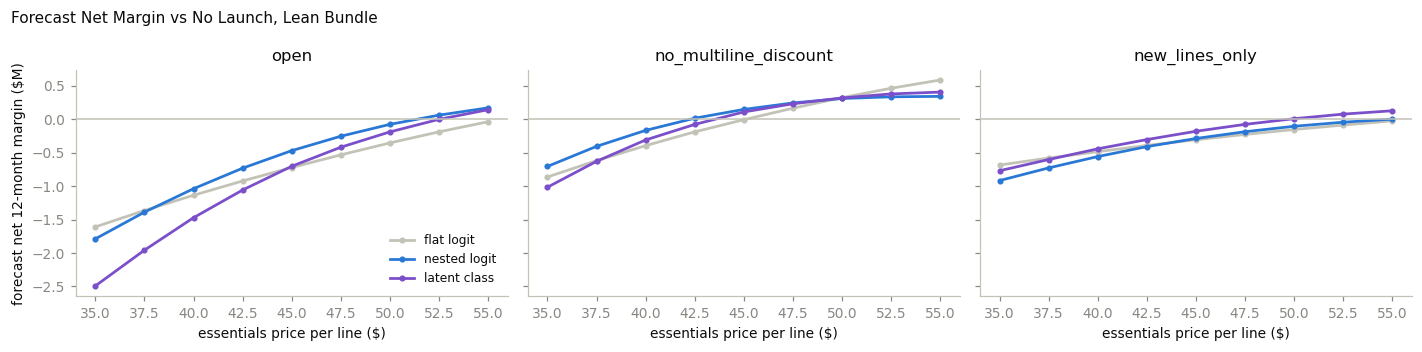

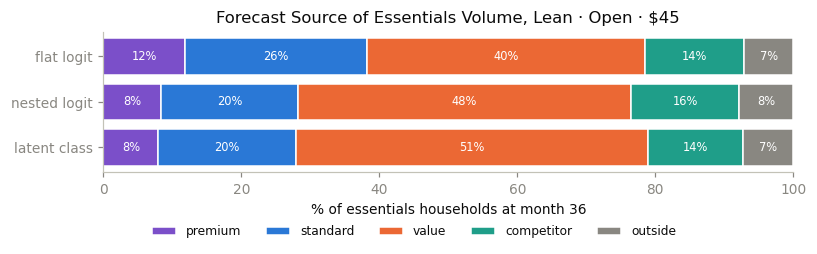

In [17]:
# Summarize Launch Forecasts
reference_summary = pd.DataFrame({
    model: {
        'essentials households': forecast_volume[model].loc[REFERENCE_CONFIG].sum(),
        'from premium + standard': forecast_volume[model].loc[REFERENCE_CONFIG, ['premium', 'standard']].sum() / forecast_volume[model].loc[REFERENCE_CONFIG].sum(),
        'from value': forecast_volume[model].loc[REFERENCE_CONFIG, 'value'] / forecast_volume[model].loc[REFERENCE_CONFIG].sum(),
        'from competitor + outside': forecast_volume[model].loc[REFERENCE_CONFIG, ['competitor', 'outside']].sum() / forecast_volume[model].loc[REFERENCE_CONFIG].sum(),
        'net 12-month margin ($M)': forecast_margin[model].loc[REFERENCE_CONFIG] / 1e6,
        'best configuration': ' · '.join(str(k) for k in forecast_margin[model].idxmax()),
        'best net margin ($M)': forecast_margin[model].max() / 1e6,
    }
    for model in MODELS
}).T
display(reference_summary.style.format({'essentials households': '{:,.0f}', 'from premium + standard': '{:.1%}', 'from value': '{:.1%}',
                                        'from competitor + outside': '{:.1%}', 'net 12-month margin ($M)': '{:+.3f}', 'best net margin ($M)': '{:+.3f}'})
        .set_caption('Forecasts at Lean · Open · $45, and Each Model\'s Best Configuration'))

fig, axes = plt.subplots(1, 3, figsize = (13, 3.2), sharey = True)
for ax, eligibility in zip(axes, ELIGIBILITY):
    for (model, series), color in zip(forecast_margin.items(), [BASELINE, ACCENT, PURPLE]):
        s = series.xs(('lean', eligibility), level = ['bundle', 'eligibility']) / 1e6
        ax.plot(s.index, s.values, marker = 'o', markersize = 3, linewidth = 1.8, color = color, label = model)
    ax.axhline(0, color = BASELINE, linewidth = 1)
    ax.set_title(eligibility)
    ax.set_xlabel('essentials price per line ($)')
axes[0].set_ylabel('forecast net 12-month margin ($M)')
axes[0].legend(frameon = False, fontsize = 8)
fig.suptitle('Forecast Net Margin vs No Launch, Lean Bundle', fontsize = 10, x = 0.01, ha = 'left')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize = (7.5, 2.6))
left = np.zeros(len(MODELS))
for origin, color in zip(ORIGINS, [PURPLE, ACCENT, ACCENT2, TEAL, MUTED]):
    values = np.array([forecast_volume[m].loc[REFERENCE_CONFIG, origin] / forecast_volume[m].loc[REFERENCE_CONFIG].sum() * 100 for m in MODELS])
    ax.barh(list(MODELS), values, left = left, color = color, edgecolor = SURFACE, label = origin)
    for i, (l, v) in enumerate(zip(left, values)):
        if v > 7:
            ax.text(l + v / 2, i, f'{v:.0f}%', ha = 'center', va = 'center', fontsize = 7.5, color = SURFACE)
    left += values
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('% of essentials households at month 36')
ax.set_title('Forecast Source of Essentials Volume, Lean · Open · $45')
ax.legend(frameon = False, fontsize = 8, ncol = 5, loc = 'upper center', bbox_to_anchor = (0.45, -0.3))
plt.tight_layout()
plt.show()

In [18]:
# Export Launch Forecasts
exports = {
    'launch_forecast_volume': pd.concat({m: v for m, v in forecast_volume.items()}, names = ['model']).reset_index(),
    'launch_forecast_margin': pd.concat({m: s for m, s in forecast_margin.items()}, names = ['model']).reset_index(),
}
paths = [save_output(df, name) for name, df in exports.items()]
display(pd.DataFrame({'rows': [len(df) for df in exports.values()], 'size (MB)': [round(p.stat().st_size / 1e6, 3) for p in paths]},
                     index = [p.name for p in paths]).rename_axis(None))

,rows,size (MB)
launch_forecast_volume.parquet,324,0.015
launch_forecast_margin.parquet,324,0.007


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>07 · Scoring Against the Answer Key</h1>
<p><strong>Purpose:</strong> Scores every model's launch forecast against the true outcome of each configuration. This is where the study's central claim is tested: that a flat logit overstates how much a cheaper plan takes from higher-margin plans, and by how much.</p>
<p><strong>Architecture:</strong> One harness scores every forecast the same way. A forecast is two tables: <code>volume</code>, households on <code>essentials</code> at month 12 by configuration and origin, and <code>net_margin</code>, 12-month margin versus no launch by configuration.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Metric</th><th style="text-align: left;">Definition</th><th style="text-align: left;">Why it matters</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">Volume error</td><td style="text-align: left; vertical-align: top;">Forecast minus true <code>essentials</code> households, as a share of truth</td><td style="text-align: left; vertical-align: top;">Take rate sizes the launch but does not decide it.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Origin distance</td><td style="text-align: left; vertical-align: top;">Total variation distance between forecast and true origin shares</td><td style="text-align: left; vertical-align: top;">Overall accuracy of the source of volume.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">High-margin share bias</td><td style="text-align: left; vertical-align: top;">Forecast minus true share drawn from <code>premium</code> and <code>standard</code></td><td style="text-align: left; vertical-align: top;">The cannibalization error itself, with its direction.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Margin error and sign agreement</td><td style="text-align: left; vertical-align: top;">Forecast minus true net margin; share of configurations where both agree on profit or loss</td><td style="text-align: left; vertical-align: top;">Whether the forecast gets the go or no-go right.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Decision regret</td><td style="text-align: left; vertical-align: top;">True margin of the best configuration minus true margin of the one the forecast picks</td><td style="text-align: left; vertical-align: top;">What following this forecast would actually cost.</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · The Scoring Harness</h2>
<p><strong>Purpose:</strong> Builds the true outcome for each configuration from the answer key and defines the scoring function every forecast passes through.</p>
<p><strong>Design Notes:</strong></p>
<ol>
<li>Origins are collapsed to what a model can forecast: <code>premium</code>, <code>standard</code>, <code>value</code>, <code>competitor</code>, and <code>outside</code></li>
<li>A household's origin is its month-12 state in the world without <code>essentials</code>, so saved churners count as <code>competitor</code> or <code>outside</code>, not as downgrades</li>
<li>The chosen configuration is the forecast's highest net margin; regret is measured in true dollars</li>
</ol>
</div>

In [19]:
# Build Answer Key Outcomes
def true_outcomes():

    grid = load_answer_key('counterfactual_grid')
    on_essentials = grid[grid['state_b'] == 'essentials'].assign(origin = lambda d: d['state_a'].map(ORIGIN_OF))

    volume = (
        on_essentials.groupby(CONFIG_KEYS + ['origin'])['households'].sum()
            .unstack('origin').reindex(columns = ORIGINS).fillna(0)
    )
    net_margin = (grid.groupby(CONFIG_KEYS)['margin_b'].sum() - grid.groupby(CONFIG_KEYS)['margin_a'].sum()).rename('net_margin')

    return volume, net_margin.reindex(volume.index)

true_volume, true_margin = true_outcomes()
print(f'{len(true_volume)} configurations · {true_volume.to_numpy().sum():,.0f} essentials households across all of them')

108 configurations · 536,443 essentials households across all of them


In [20]:
# Define Scoring Harness
def score_forecast(volume, net_margin, truth = (true_volume, true_margin)):

    t_volume, t_margin = truth
    volume = volume.reindex(index = t_volume.index, columns = ORIGINS)
    net_margin = net_margin.reindex(t_volume.index)
    if volume.isna().any().any() or net_margin.isna().any():
        raise ValueError('forecast must cover every configuration and origin')

    f_total, t_total = volume.sum(axis = 1), t_volume.sum(axis = 1)
    f_share, t_share = volume.div(f_total, axis = 0), t_volume.div(t_total, axis = 0)
    high = ['premium', 'standard']

    by_config = pd.DataFrame({
        'volume error': (f_total - t_total) / t_total,
        'origin distance': 0.5 * (f_share - t_share).abs().sum(axis = 1),
        'high-margin share bias': f_share[high].sum(axis = 1) - t_share[high].sum(axis = 1),
        'margin error ($M)': (net_margin - t_margin) / 1e6,
        'sign agrees': np.sign(net_margin) == np.sign(t_margin),
    })

    chosen = net_margin.idxmax()
    summary = pd.Series({
        'mean |volume error|': by_config['volume error'].abs().mean(),
        'mean origin distance': by_config['origin distance'].mean(),
        'mean high-margin share bias': by_config['high-margin share bias'].mean(),
        'margin RMSE ($M)': np.sqrt((by_config['margin error ($M)'] ** 2).mean()),
        'margin sign agreement': by_config['sign agrees'].mean(),
        'chosen configuration': ' · '.join(str(k) for k in chosen),
        'decision regret ($M)': (t_margin.max() - t_margin.loc[chosen]) / 1e6,
    })

    return by_config, summary

<hr>
<div>
<h2>2 · Harness Checks</h2>
<p><strong>Purpose:</strong> Confirms the harness measures what it claims before any real forecast is scored, using three constructed forecasts.</p>
<p><strong>Design Notes:</strong></p>
<ol>
<li><strong>Truth:</strong> the answer key scored against itself must show zero error on every metric</li>
<li><strong>Inflated volume:</strong> every origin scaled up 20% must show a 20% volume error and no origin error</li>
<li><strong>Proportional origins:</strong> true totals, but split across origins in proportion to month-24 market shares, the way a flat logit would; it must show origin error and a positive high-margin share bias, with no volume error</li>
<li>These are checks on the harness, not forecasts; no model has been scored yet</li>
</ol>
</div>

In [21]:
# Run Harness Checks
truth_forecast = score_forecast(true_volume, true_margin)

inflated_forecast = score_forecast(true_volume * 1.2, true_margin)

month_24_shares = (
    load_answer_key('ground_truth')['plan_month_24'].map(ORIGIN_OF).value_counts(normalize = True).reindex(ORIGINS)
)
proportional_volume = pd.DataFrame(
    np.outer(true_volume.sum(axis = 1), month_24_shares), index = true_volume.index, columns = ORIGINS
)
proportional_forecast = score_forecast(proportional_volume, true_margin)

harness_checks = pd.DataFrame({
    'truth': truth_forecast[1],
    'inflated volume': inflated_forecast[1],
    'proportional origins': proportional_forecast[1],
})
display(harness_checks.map(lambda v: round(v, 4) + 0.0 if isinstance(v, float) else v).rename_axis(None))

,truth,inflated volume,proportional origins
mean |volume error|,0.0,0.2,0.0
mean origin distance,0.0,0.0,0.4233
mean high-margin share bias,0.0,0.0,0.2902
margin RMSE ($M),0.0,0.0,0.0
margin sign agreement,1.0,1.0,1.0
chosen configuration,lean_hd · new_lines_only · 40.0,lean_hd · new_lines_only · 40.0,lean_hd · new_lines_only · 40.0
decision regret ($M),0.0,0.0,0.0


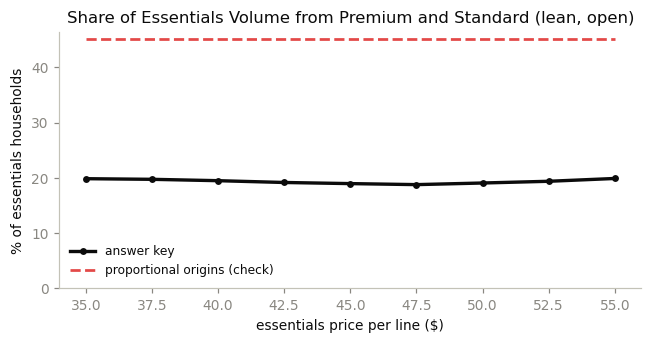

In [22]:
# Plot: Harness Check on the Reference Bundle
bundle, eligibility, _ = REFERENCE_CONFIG
prices = ESSENTIALS_PRICES
high = ['premium', 'standard']

def high_share(volume):
    v = volume.xs((bundle, eligibility), level = ['bundle', 'eligibility'])
    return v[high].sum(axis = 1) / v.sum(axis = 1)

fig, ax = plt.subplots(figsize = (6, 3.2))
ax.plot(prices, high_share(true_volume) * 100, color = INK, linewidth = 2.2, marker = 'o', markersize = 3.5, label = 'answer key')
ax.plot(prices, high_share(proportional_volume) * 100, color = RED, linewidth = 1.8, linestyle = '--', label = 'proportional origins (check)')
ax.set_ylim(bottom = 0)
ax.set_title('Share of Essentials Volume from Premium and Standard (lean, open)')
ax.set_xlabel('essentials price per line ($)')
ax.set_ylabel('% of essentials households')
ax.legend(frameon = False, fontsize = 8)
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>3 · Flat vs Nested vs Latent Class</h2>
<p><strong>Purpose:</strong> Scores each model's section 06 forecast against the true outcome of all 108 configurations.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Same Harness for Every Model.</strong> Each forecast passes through the section 1 harness unchanged, so differences in scores come from the models, not the scoring.</li>
<li style="margin-bottom: 0.7em;"><strong>Cannibalization Test.</strong> The study's central claim is that a flat logit overstates how much a cheaper plan takes from <code>premium</code> and <code>standard</code>. The high-margin share bias tests it directly, with its direction.</li>
<li style="margin-bottom: 0.7em;"><strong>Decision Test.</strong> Accurate volumes matter less than choosing well. Each model's chosen configuration is valued at its true margin, and compared with the best configuration in the grid.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [23]:
# Score Model Forecasts
model_scores = {model: score_forecast(forecast_volume[model], forecast_margin[model]) for model in MODELS}
score_summary = pd.DataFrame({model: scores[1] for model, scores in model_scores.items()}).T
best_true = true_margin.idxmax()
score_summary['chosen configuration, true margin ($M)'] = [true_margin.loc[forecast_margin[m].idxmax()] / 1e6 for m in MODELS]

display(score_summary.style.format({
    'mean |volume error|': '{:.1%}', 'mean origin distance': '{:.1%}', 'mean high-margin share bias': '{:+.1%}',
    'margin RMSE ($M)': '{:.3f}', 'margin sign agreement': '{:.1%}', 'decision regret ($M)': '{:.3f}',
    'chosen configuration, true margin ($M)': '{:+.3f}',
}).set_caption(f"Forecast Scores across 108 Configurations · best true configuration: {' · '.join(str(k) for k in best_true)} (+${true_margin.max() / 1e6:.3f}M)"))

,mean |volume error|,mean origin distance,mean high-margin share bias,margin RMSE ($M),margin sign agreement,chosen configuration,decision regret ($M),"chosen configuration, true margin ($M)"
flat logit,71.3%,23.7%,+20.2%,0.562,42.6%,lean_hd · no_multiline_discount · 55.0,0.145,+0.229
nested logit,40.6%,17.8%,+9.7%,0.516,59.3%,lean_hd · no_multiline_discount · 55.0,0.145,+0.229
latent class,50.9%,18.4%,+8.8%,0.615,58.3%,lean_hd · no_multiline_discount · 55.0,0.145,+0.229


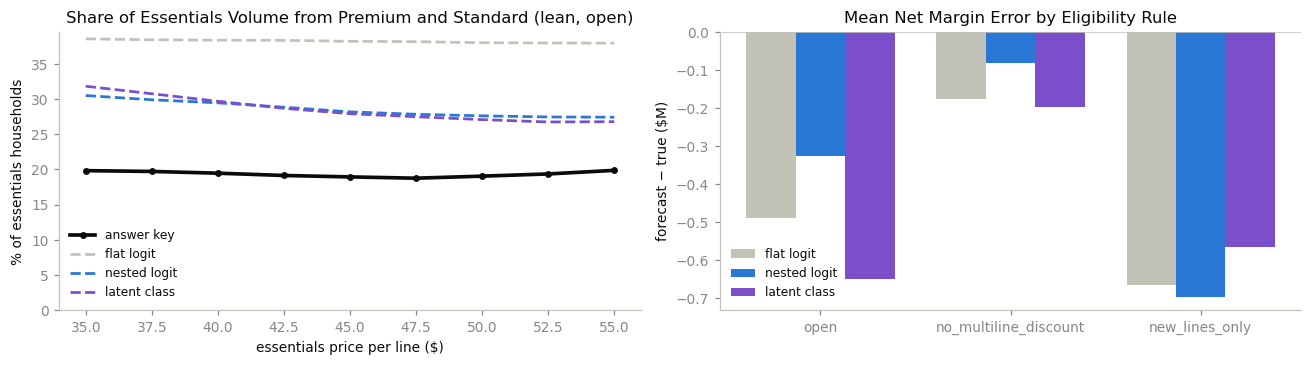

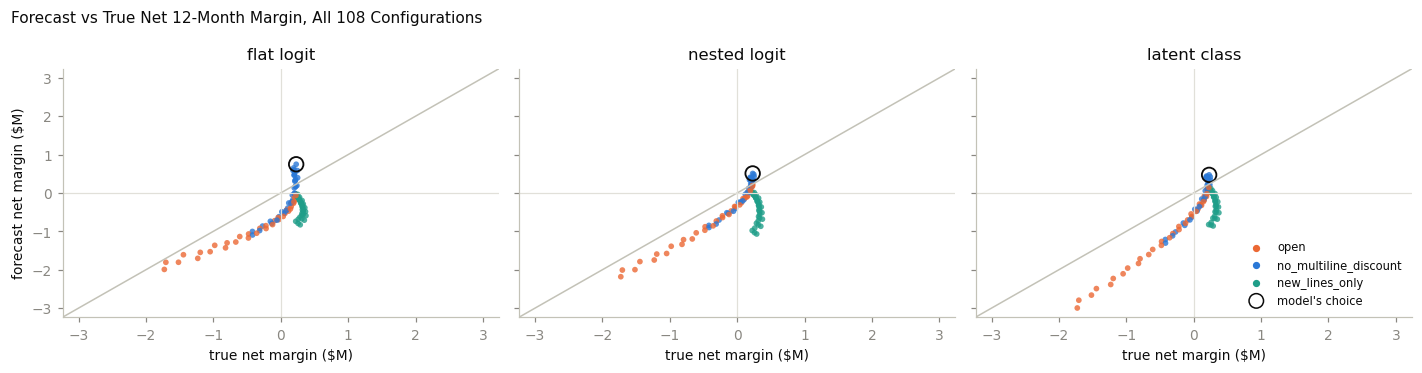

In [24]:
# Plot: Forecasts vs Truth
bundle, eligibility, _ = REFERENCE_CONFIG
model_colors = dict(zip(MODELS, [BASELINE, ACCENT, PURPLE]))

fig, axes = plt.subplots(1, 2, figsize = (12, 3.4))
axes[0].plot(ESSENTIALS_PRICES, high_share(true_volume) * 100, color = INK, linewidth = 2.4, marker = 'o', markersize = 3.5, label = 'answer key')
for model in MODELS:
    axes[0].plot(ESSENTIALS_PRICES, high_share(forecast_volume[model]) * 100, color = model_colors[model], linewidth = 1.8, linestyle = '--', label = model)
axes[0].set_ylim(bottom = 0)
axes[0].set_title('Share of Essentials Volume from Premium and Standard (lean, open)')
axes[0].set_xlabel('essentials price per line ($)')
axes[0].set_ylabel('% of essentials households')
axes[0].legend(frameon = False, fontsize = 8)

by_eligibility = pd.DataFrame({
    model: (forecast_margin[model] - true_margin).groupby(level = 'eligibility').mean() / 1e6 for model in MODELS
}).reindex(ELIGIBILITY)
x = np.arange(len(ELIGIBILITY))
width = 0.26
for k, model in enumerate(MODELS):
    axes[1].bar(x + (k - 1) * width, by_eligibility[model], width, color = model_colors[model], label = model)
axes[1].axhline(0, color = BASELINE, linewidth = 1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ELIGIBILITY)
axes[1].set_title('Mean Net Margin Error by Eligibility Rule')
axes[1].set_ylabel('forecast − true ($M)')
axes[1].legend(frameon = False, fontsize = 8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(MODELS), figsize = (13, 3.4), sharex = True, sharey = True)
limit = max(abs(true_margin).max(), *(abs(forecast_margin[m]).max() for m in MODELS)) / 1e6 * 1.08
for ax, model in zip(axes, MODELS):
    ax.plot([-limit, limit], [-limit, limit], color = BASELINE, linewidth = 1)
    ax.axhline(0, color = GRID, linewidth = 0.8)
    ax.axvline(0, color = GRID, linewidth = 0.8)
    colors = [dict(zip(ELIGIBILITY, [ACCENT2, ACCENT, TEAL]))[e] for e in true_margin.index.get_level_values('eligibility')]
    ax.scatter(true_margin / 1e6, forecast_margin[model].reindex(true_margin.index) / 1e6, s = 14, c = colors, alpha = 0.8, linewidths = 0)
    chosen = forecast_margin[model].idxmax()
    ax.scatter(true_margin.loc[chosen] / 1e6, forecast_margin[model].loc[chosen] / 1e6, s = 90, facecolors = 'none', edgecolors = INK, linewidths = 1.2)
    ax.set_title(model)
    ax.set_xlabel('true net margin ($M)')
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
axes[0].set_ylabel('forecast net margin ($M)')
for eligibility, color in zip(ELIGIBILITY, [ACCENT2, ACCENT, TEAL]):
    axes[-1].scatter([], [], color = color, s = 14, label = eligibility)
axes[-1].scatter([], [], s = 90, facecolors = 'none', edgecolors = INK, label = "model's choice")
axes[-1].legend(frameon = False, fontsize = 7.5, loc = 'lower right')
fig.suptitle('Forecast vs True Net 12-Month Margin, All 108 Configurations', fontsize = 10, x = 0.01, ha = 'left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>4 · Where Forecasts Go Wrong</h2>
<p><strong>Purpose:</strong> Breaks each model's forecast error down by eligibility rule, bundle, and price, to show which parts of the decision the forecasts can and cannot be trusted on.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Breakdowns.</strong> Mean volume error, mean high-margin share bias, and mean net margin error within each eligibility rule, bundle, and price, using the section 1 per-configuration scores.</li>
<li style="margin-bottom: 0.7em;"><strong>Direction Matters.</strong> Errors are signed. A forecast that is consistently too pessimistic about one fence and too optimistic about another would reorder configurations even if its average error were small.</li>
<li style="margin-bottom: 0.7em;"><strong>Ranking.</strong> Spearman rank correlation between forecast and true net margin, overall and within each eligibility rule, measures whether the forecast orders configurations correctly, which is what the recommendation depends on.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [25]:
# Break Down Forecast Error
from scipy.stats import spearmanr

breakdown_metrics = ['volume error', 'high-margin share bias', 'margin error ($M)']
for level in ['eligibility', 'bundle', 'essentials_price']:
    table = pd.concat({
        model: scores[0][breakdown_metrics].groupby(level = level).mean() for model, scores in model_scores.items()
    }, axis = 1)
    if level != 'essentials_price':
        table = table.reindex(ELIGIBILITY if level == 'eligibility' else ESSENTIALS_BUNDLES)
    display(table.style.format({c: ('{:+.1%}' if c[1] != 'margin error ($M)' else '{:+.3f}') for c in table.columns})
            .set_caption(f'Mean Signed Error by {level.replace("_", " ")}'))

ranking = pd.DataFrame({
    model: {
        'all configurations': spearmanr(forecast_margin[model].reindex(true_margin.index), true_margin).statistic,
        **{f'within {e}': spearmanr(forecast_margin[model].xs(e, level = 'eligibility'),
                                    true_margin.xs(e, level = 'eligibility').reindex(forecast_margin[model].xs(e, level = 'eligibility').index)).statistic
           for e in ELIGIBILITY},
    }
    for model in MODELS
}).T
display(ranking.style.format('{:.2f}').set_caption('Rank Correlation between Forecast and True Net Margin'))

,all configurations,within open,within no_multiline_discount,within new_lines_only
flat logit,0.52,1.00,0.83,-0.47
nested logit,0.33,1.00,0.88,-0.45
latent class,0.51,1.00,0.83,-0.45


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>08 · Recommendation and Rollout Design</h1>
<p><strong>Purpose:</strong> Chooses a launch configuration the way the carrier would, from the forecasts alone; shows how far the forecasts would have to be wrong for a different configuration to win; and designs a rollout that measures the real effect where the forecasts are weakest.</p>
<p><strong>Architecture:</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Reasoning</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1</td><td style="text-align: left; vertical-align: top;">Robust choice across models with a cannibalization ceiling</td><td style="text-align: left; vertical-align: top;">No single model is trustworthy enough to follow alone; choosing the best worst case, and capping the draw from high-margin plans, protects against forecast error in the costliest direction.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2</td><td style="text-align: left; vertical-align: top;">Decision boundary over price response and launch-driven acquisition</td><td style="text-align: left; vertical-align: top;">Section 07 found the forecasts too unresponsive to price and too pessimistic about new customers; the boundary shows whether either would change the decision.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3</td><td style="text-align: left; vertical-align: top;">Market-randomized rollout with holdout markets and price cells, sized from historical placebo tests</td><td style="text-align: left; vertical-align: top;">A launch designed as an experiment measures the effect directly and supplies the price variation the history lacked.</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Choosing Price, Bundle, and Eligibility</h2>
<p><strong>Purpose:</strong> Applies a decision rule to the section 06 forecasts, then scores the decision it makes against the answer key.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Decision Rule.</strong> For every configuration, take the lowest forecast 12-month net margin across the three models. Keep configurations whose median forecast share of volume from <code>premium</code> and <code>standard</code> across the models is at most 30%; the median keeps one model's view of cannibalization from vetoing every option. Choose the one with the highest worst-case margin. If no configuration meets the ceiling, the lowest-share configurations are considered instead.</li>
<li style="margin-bottom: 0.7em;"><strong>Forecasts Only.</strong> The rule uses nothing from the answer key. The carrier would not have one, and a recommendation chosen with it would score itself.</li>
<li style="margin-bottom: 0.7em;"><strong>Price Range.</strong> A choice at the highest or lowest tested price means the forecasts would prefer a price outside the grid; the recommendation then describes the best price tested, not a proven optimum.</li>
<li style="margin-bottom: 0.7em;"><strong>Scoring the Decision.</strong> After the choice is made, the answer key values it, each model's own choice, and the best configuration in the grid, in true net margin and true share of volume from high-margin plans.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [26]:
# Apply Robust Decision Rule
HIGH_MARGIN_CEILING = 0.30

forecast_margins = pd.DataFrame(forecast_margin)
forecast_high_share = pd.DataFrame({m: forecast_volume[m][['premium', 'standard']].sum(axis = 1) / forecast_volume[m].sum(axis = 1) for m in MODELS})
candidates = pd.DataFrame({
    'worst-case margin ($M)': forecast_margins.min(axis = 1) / 1e6,
    'median margin ($M)': forecast_margins.median(axis = 1) / 1e6,
    'best-case margin ($M)': forecast_margins.max(axis = 1) / 1e6,
    'median high-margin share': forecast_high_share.median(axis = 1),
    'highest high-margin share': forecast_high_share.max(axis = 1),
})
candidates['within ceiling'] = candidates['median high-margin share'] <= HIGH_MARGIN_CEILING
pool = candidates[candidates['within ceiling']] if candidates['within ceiling'].any() else candidates.nsmallest(10, 'median high-margin share')
recommended = pool['worst-case margin ($M)'].idxmax()
at_price_edge = recommended[2] in (ESSENTIALS_PRICES.min(), ESSENTIALS_PRICES.max())

print(f"Recommended: {' · '.join(str(k) for k in recommended)}"
      + (' (at the edge of the tested price range)' if at_price_edge else ''))
display(candidates.sort_values('worst-case margin ($M)', ascending = False).head(8)
        .style.format({'worst-case margin ($M)': '{:+.3f}', 'median margin ($M)': '{:+.3f}', 'best-case margin ($M)': '{:+.3f}',
                       'median high-margin share': '{:.1%}', 'highest high-margin share': '{:.1%}'})
        .set_caption(f'Top Configurations by Worst-Case Forecast Margin ({candidates["within ceiling"].sum()} of {len(candidates)} within the {HIGH_MARGIN_CEILING:.0%} ceiling)'))

Recommended: lean_hd · no_multiline_discount · 52.5


In [27]:
# Score the Decision
true_high_share = true_volume[['premium', 'standard']].sum(axis = 1) / true_volume.sum(axis = 1)
decisions = {'robust rule': recommended, **{f'{m} alone': forecast_margin[m].idxmax() for m in MODELS}, 'best in grid (answer key)': true_margin.idxmax()}
decision_scores = pd.DataFrame({
    name: {
        'configuration': ' · '.join(str(k) for k in config),
        'true net margin ($M)': true_margin.loc[config] / 1e6,
        'true share from premium + standard': true_high_share.loc[config],
        'true essentials households': true_volume.loc[config].sum(),
        'regret vs best ($M)': (true_margin.max() - true_margin.loc[config]) / 1e6,
    }
    for name, config in decisions.items()
}).T
display(decision_scores.style.format({'true net margin ($M)': '{:+.3f}', 'true share from premium + standard': '{:.1%}',
                                      'true essentials households': '{:,.0f}', 'regret vs best ($M)': '{:.3f}'})
        .set_caption('How the Decisions Score against the Answer Key'))

,configuration,true net margin ($M),true share from premium + standard,true essentials households,regret vs best ($M)
robust rule,lean_hd · no_multiline_discount · 52.5,+0.246,23.8%,"1,841",0.128
flat logit alone,lean_hd · no_multiline_discount · 55.0,+0.229,25.6%,"1,344",0.145
nested logit alone,lean_hd · no_multiline_discount · 55.0,+0.229,25.6%,"1,344",0.145
latent class alone,lean_hd · no_multiline_discount · 55.0,+0.229,25.6%,"1,344",0.145
best in grid (answer key),lean_hd · new_lines_only · 40.0,+0.374,6.4%,"4,116",0.000


<hr>
<div>
<h2>2 · Decision Boundary</h2>
<p><strong>Purpose:</strong> Re-runs the forecast under stronger price response and stronger launch-driven acquisition, the two weaknesses section 07 found, to show whether either would change the recommendation.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Price Response.</strong> Every price coefficient, for customers, new customers, and staying put, is multiplied by 1, 1.5, or 2. Arrivals are recalibrated under each multiplier so baseline gross adds still match history.</li>
<li style="margin-bottom: 0.7em;"><strong>Launch-Driven Acquisition.</strong> The extra arrivals during launch months, above the steady rate, are multiplied by 1, 1.5, or 2.</li>
<li style="margin-bottom: 0.7em;"><strong>Scope.</strong> The recommended bundle's 27 configurations (every eligibility rule and price), each model, one replication on shared draws. The same robust rule and ceiling pick a winner in each of the nine scenarios.</li>
<li style="margin-bottom: 0.7em;"><strong>Reading the Grid.</strong> Scenarios where the winner matches the recommendation are regions where the decision is safe from these errors. A change of fence or a large change of price marks the boundary.</li>
<li style="margin-bottom: 0.7em;"><strong>Scored Separately.</strong> The true margin of each scenario's winner is shown afterward. It is not used to pick a scenario: in practice the carrier would not know which one is true.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [28]:
# Simulate Decision Boundary Scenarios
PRICE_RESPONSE = [1.0, 1.5, 2.0]
ARRIVAL_RESPONSE = [1.0, 1.5, 2.0]
boundary_configs = [(recommended[0], e, p) for e in ELIGIBILITY for p in ESSENTIALS_PRICES]


def scale_price_response(market, multiple):
    scaled = dict(market)
    for key in ['X', 'prospect_X']:
        features = market[key].copy()
        features[..., 0] *= multiple
        scaled[key] = features
    stay = market['prospect_stay_X'].copy()
    stay[:, 0] *= multiple
    scaled['prospect_stay_X'] = stay
    return scaled

started = time.time()
boundary_margin, boundary_high = {}, {}
for model, fit in launch_fits.items():
    steady = {k: int(round(steady_adds / prospect_join_probability(model, scale_price_response(reference_market, k), fit, ['premium', 'standard', 'value'])))
              for k in PRICE_RESPONSE}
    slots = int(np.ceil(max(steady.values()) * (1 + (arrival_multiplier - 1) * max(ARRIVAL_RESPONSE))))
    draws = make_draws(model, reference_market, fit, HORIZON, slots, replication = 0)
    for k in PRICE_RESPONSE:
        without = simulate_market(model, scale_price_response(reference_market, k), fit, HORIZON, False, LAUNCH_MONTHS, slots, 0,
                                  active_arrivals = {m: steady[k] for m in HORIZON}, draws = draws)
        for a in ARRIVAL_RESPONSE:
            active = {m: int(round(steady[k] * ((1 + (arrival_multiplier - 1) * a) if m in LAUNCH_MONTHS else 1))) for m in HORIZON}
            for config in boundary_configs:
                market = scale_price_response(markets_by_config[config], k)
                with_launch = simulate_market(model, market, fit, HORIZON, True, LAUNCH_MONTHS, slots, 0,
                                              launch_lift = intensity, active_arrivals = active, draws = draws)
                volume = source_of_volume(with_launch, without, market, 'essentials')
                boundary_margin[(k, a, model, config)] = with_launch['margin'] - without['margin']
                boundary_high[(k, a, model, config)] = volume[['premium', 'standard']].sum() / max(volume.sum(), 1)
print(f'{len(boundary_margin):,} scenario runs in {time.time() - started:,.0f} seconds')

rows = []
for k in PRICE_RESPONSE:
    for a in ARRIVAL_RESPONSE:
        worst = pd.Series({c: min(boundary_margin[(k, a, m, c)] for m in MODELS) for c in boundary_configs})
        ceiling_ok = pd.Series({c: np.median([boundary_high[(k, a, m, c)] for m in MODELS]) <= HIGH_MARGIN_CEILING for c in boundary_configs})
        pool = worst[ceiling_ok] if ceiling_ok.any() else worst
        winner = pool.idxmax()
        rows.append({'price response': k, 'launch acquisition': a, 'winner': winner, 'eligibility': winner[1], 'price': winner[2],
                     'worst-case margin ($M)': pool.max() / 1e6, 'true margin of winner ($M)': true_margin.loc[winner] / 1e6,
                     'matches recommendation': winner == recommended})
boundary = pd.DataFrame(rows)

display(boundary.pivot(index = 'price response', columns = 'launch acquisition', values = 'winner')
        .map(lambda c: f'{c[1]} · ${c[2]:.2f}').rename_axis('price response ↓ · launch acquisition →', axis = 0)
        .style.set_caption(f'Winning Configuration by Scenario ({recommended[0]} bundle)'))

729 scenario runs in 109 seconds


launch acquisition,1.000000,1.500000,2.000000
price response ↓ · launch acquisition →,,,
1.000000,no_multiline_discount · $50.00,no_multiline_discount · $55.00,no_multiline_discount · $55.00
1.500000,no_multiline_discount · $52.50,no_multiline_discount · $55.00,no_multiline_discount · $55.00
2.000000,no_multiline_discount · $50.00,no_multiline_discount · $50.00,no_multiline_discount · $50.00


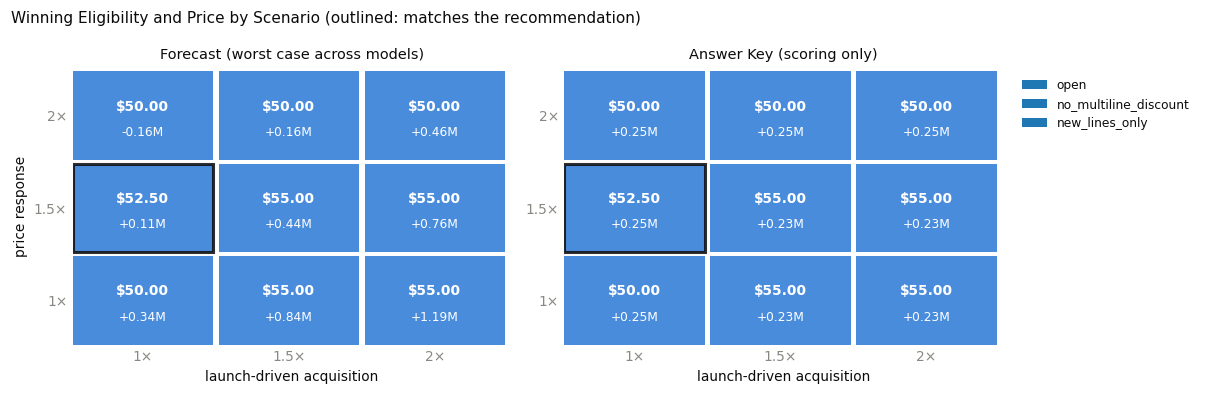

In [29]:
# Plot: Decision Boundary
eligibility_colors = dict(zip(ELIGIBILITY, [ACCENT2, ACCENT, TEAL]))
fig, axes = plt.subplots(1, 2, figsize = (11, 3.6))
for ax, value, title in [(axes[0], 'worst-case margin ($M)', 'Forecast (worst case across models)'),
                         (axes[1], 'true margin of winner ($M)', 'Answer Key (scoring only)')]:
    for _, row in boundary.iterrows():
        i, j = PRICE_RESPONSE.index(row['price response']), ARRIVAL_RESPONSE.index(row['launch acquisition'])
        ax.add_patch(plt.Rectangle((j, i), 0.96, 0.96, color = eligibility_colors[row['eligibility']], alpha = 0.85,
                                   ec = INK if row['matches recommendation'] else SURFACE, lw = 2 if row['matches recommendation'] else 0))
        ax.text(j + 0.48, i + 0.58, f"${row['price']:.2f}", ha = 'center', va = 'center', fontsize = 9, color = SURFACE, fontweight = 'bold')
        ax.text(j + 0.48, i + 0.3, f"{row[value]:+.2f}M", ha = 'center', va = 'center', fontsize = 8, color = SURFACE)
    ax.set_xlim(0, len(ARRIVAL_RESPONSE))
    ax.set_ylim(0, len(PRICE_RESPONSE))
    ax.set_xticks(np.arange(len(ARRIVAL_RESPONSE)) + 0.48)
    ax.set_xticklabels([f'{a:g}×' for a in ARRIVAL_RESPONSE])
    ax.set_yticks(np.arange(len(PRICE_RESPONSE)) + 0.48)
    ax.set_yticklabels([f'{k:g}×' for k in PRICE_RESPONSE])
    ax.set_xlabel('launch-driven acquisition')
    ax.set_title(title, fontsize = 9.5)
    ax.spines[['left', 'bottom']].set_visible(False)
    ax.tick_params(length = 0)
axes[0].set_ylabel('price response')
for eligibility, color in eligibility_colors.items():
    axes[1].bar([], [], color = color, label = eligibility)
axes[1].legend(frameon = False, fontsize = 8, loc = 'upper left', bbox_to_anchor = (1.02, 1.0))
fig.suptitle('Winning Eligibility and Price by Scenario (outlined: matches the recommendation)', fontsize = 10, x = 0.01, ha = 'left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>3 · Rollout and Measurement Design</h2>
<p><strong>Purpose:</strong> Designs a rollout that measures the launch's real effect, sized from how noisy market-level outcomes have actually been.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Design.</strong> Markets are randomized to launch or holdout, stratified by competitive intensity, and the effect is read by difference-in-differences: the change in launch markets minus the change in holdout markets over the same months.</li>
<li style="margin-bottom: 0.7em;"><strong>Outcomes.</strong> Two, both per account at the start of the window, with accounts that leave counting as zero margin and off the carrier's plans:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Average monthly contribution margin, the decision metric.</li>
<li>Share still on <code>premium</code> or <code>standard</code>, the cannibalization metric.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Precision from History.</strong> Placebo tests on months 13–18 and 19–24: markets are split at random thousands of times, with no launch in either group, and the spread of the difference-in-differences estimates is the standard error a real rollout would face. Minimum detectable effect is 2.8 standard errors (80% power, 5% two-sided).</li>
<li style="margin-bottom: 0.7em;"><strong>Price Cells.</strong> Splitting launch markets across prices supplies the price variation the history lacked. Its precision is the placebo standard error for comparing two cells of a three-way split.</li>
<li style="margin-bottom: 0.7em;"><strong>Forecast Effect.</strong> The recommended configuration's median forecast net margin across models, per starting account per month, and its forecast share of starting accounts moving off <code>premium</code> or <code>standard</code>.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><em>To be written once results are final.</em></li>
</ol>
</div>

In [30]:
# Estimate Measurement Precision from History
def window_outcomes(start, length = 6):
    """Per market: mean monthly margin per starting account, and share of starting accounts on premium or standard at the end."""
    starting = usage_panel.loc[usage_panel['month'] == start, ['account_id', 'plan']]
    window = usage_panel[usage_panel['month'].between(start, start + length - 1) & usage_panel['account_id'].isin(starting['account_id'])]
    margin = window.groupby('account_id')['margin'].sum().reindex(starting['account_id'], fill_value = 0.0) / length
    end_plan = window[window['month'] == start + length - 1].set_index('account_id')['plan'].reindex(starting['account_id'])
    frame = pd.DataFrame({'margin': margin.to_numpy(), 'high': end_plan.isin(['premium', 'standard']).to_numpy(),
                          'market_id': accounts.loc[starting['account_id'], 'market_id'].to_numpy()})
    return frame.groupby('market_id').agg(margin = ('margin', 'mean'), high = ('high', 'mean'), accounts = ('margin', 'size'))

before, after = window_outcomes(13), window_outcomes(19)
change = (after[['margin', 'high']] - before[['margin', 'high']]).assign(weight = after['accounts'])
strata = pd.qcut(markets.loc[change.index, 'competitive_intensity'], 4, labels = False).to_numpy()
placebo_rng = np.random.default_rng(SEED)


def placebo_se(n_first, n_second, draws = 4000):
    """Standard error of a difference-in-differences between two disjoint groups of markets, drawn within strata, with no launch."""
    w = change['weight'].to_numpy()
    values = change[['margin', 'high']].to_numpy()
    estimates = []
    for _ in range(draws):
        first, second = np.zeros(len(change), dtype = bool), np.zeros(len(change), dtype = bool)
        for stratum in np.unique(strata):
            members = placebo_rng.permutation(np.flatnonzero(strata == stratum))
            a = int(round(n_first * len(members) / len(change)))
            b = int(round(n_second * len(members) / len(change)))
            first[members[:a]] = True
            second[members[a:a + b]] = True
        estimates.append(np.average(values[first], axis = 0, weights = w[first]) - np.average(values[second], axis = 0, weights = w[second]))
    return np.std(estimates, axis = 0)

recommended_margin = np.median([forecast_margin[m].loc[recommended] for m in MODELS])
starting_accounts = len(launch_population['customers'])
effect_margin = recommended_margin / starting_accounts / N_HORIZON
effect_high = np.median([forecast_volume[m].loc[recommended, ['premium', 'standard']].sum() for m in MODELS]) / starting_accounts

design_rows = {}
for n_holdout in [8, 12, 16, 20]:
    se_margin, se_high = placebo_se(len(change) - n_holdout, n_holdout)
    design_rows[f'{len(change) - n_holdout} launch vs {n_holdout} holdout markets'] = {
        'MDE, margin per account-month ($)': 2.8 * se_margin, 'forecast effect ($)': effect_margin,
        'MDE, share on premium/standard (points)': 2.8 * se_high * 100, 'forecast effect (points)': -effect_high * 100,
    }
cell_size = len(change) // 3
cell_se_margin, cell_se_high = placebo_se(cell_size, cell_size)
design_rows[f'price cells: one cell vs another ({cell_size} markets each)'] = {
    'MDE, margin per account-month ($)': 2.8 * cell_se_margin, 'forecast effect ($)': np.nan,
    'MDE, share on premium/standard (points)': 2.8 * cell_se_high * 100, 'forecast effect (points)': np.nan,
}
display(pd.DataFrame(design_rows).T.style.format({
    'MDE, margin per account-month ($)': '${:,.2f}', 'forecast effect ($)': '${:,.2f}',
    'MDE, share on premium/standard (points)': '{:.2f}', 'forecast effect (points)': '{:+.2f}',
}, na_rep = '—').set_caption('Minimum Detectable Effects from Historical Placebo Tests (6-month windows, 80% power)'))

,"MDE, margin per account-month ($)",forecast effect ($),"MDE, share on premium/standard (points)",forecast effect (points)
32 launch vs 8 holdout markets,$1.17,$0.96,1.95,-2.77
28 launch vs 12 holdout markets,$1.03,$0.96,1.69,-2.77
24 launch vs 16 holdout markets,$0.95,$0.96,1.58,-2.77
20 launch vs 20 holdout markets,$0.93,$0.96,1.56,-2.77
price cells: one cell vs another (13 markets each),$1.24,—,2.06,—


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h3>The Complete Study Chain</h3>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Section</th><th style="text-align: left;">Role in the study</th><th style="text-align: left;">Question it answers</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">00 · Data Generation and Validation</td><td style="text-align: left; vertical-align: top;">Creates and validates the synthetic market and the withheld answer key</td><td style="text-align: left; vertical-align: top;">What would the study need to observe, and does the synthetic market contain it?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">01 · The Revealed-Preference Baseline</td><td style="text-align: left; vertical-align: top;">Estimates plan choice from carrier history alone</td><td style="text-align: left; vertical-align: top;">What does history identify, and where does it run out?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">02 · The Stated-Preference Mixed Logit</td><td style="text-align: left; vertical-align: top;">Values plan features and their variation across customers</td><td style="text-align: left; vertical-align: top;">What is each feature worth, and to whom?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">03 · The Joint RP–SP Nested Model</td><td style="text-align: left; vertical-align: top;">Combines both data sources with realistic substitution</td><td style="text-align: left; vertical-align: top;">Which plans substitute for which?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">04 · Latent Taste Classes</td><td style="text-align: left; vertical-align: top;">Segments customers by what they value</td><td style="text-align: left; vertical-align: top;">Which groups value which features?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">05 · Back-Test on the Value Launch</td><td style="text-align: left; vertical-align: top;">Validates the method on a past launch</td><td style="text-align: left; vertical-align: top;">Would it have been right before?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">06 · The Launch Simulation</td><td style="text-align: left; vertical-align: top;">Forecasts every launch configuration</td><td style="text-align: left; vertical-align: top;">What happens at each price, bundle, and rule?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">07 · Scoring Against the Answer Key</td><td style="text-align: left; vertical-align: top;">Measures each model's forecast error</td><td style="text-align: left; vertical-align: top;">How wrong is each forecast, and in which direction?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">08 · Recommendation and Rollout Design</td><td style="text-align: left; vertical-align: top;">Turns the forecast into a launch decision</td><td style="text-align: left; vertical-align: top;">What should launch, and how will we know it worked?</td></tr>
</tbody>
</table>
</div>